In [76]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats as scipy_stats
from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats as scipy_stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import joblib

import warnings
 
warnings.filterwarnings("ignore")

**Plot Style**

In [2]:
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor":   "#1a1a1a",
    "axes.edgecolor":   "#333333",
    "axes.labelcolor":  "#cccccc",
    "xtick.color":      "#888888",
    "ytick.color":      "#888888",
    "text.color":       "#cccccc",
    "grid.color":       "#2a2a2a",
    "grid.linestyle":   "--",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "figure.titlesize": 15,
})
SPOTIFY_GREEN = "#1DB954"
PALETTE = "Set2"

<h4>Section 1: Data Understanding</h4>

**STEP 1: LOAD DATA**

In [3]:
# STEP 1: LOAD DATA
df_raw = pd.read_csv("dataset.csv")

print(f"\nRaw shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")




Raw shape : 114,000 rows × 21 columns


**STEP 2: DATA OVERVIEW**

In [4]:
print("Column Info:")
print(f"{df_raw.dtypes.to_string}")
 
print("\nFirst 5 rows:")
print(f"{df_raw.head().to_string()}")

print("\nLast 5 rows:")
print(f"{df_raw.tail().to_string()}")
 
print("\nDescriptive Statistics (numeric):")
print(f"{df_raw.describe().round(4).to_string()}")

Column Info:
<bound method Series.to_string of Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object>

First 5 rows:
   Unnamed: 0                track_id                 artists                                              album_name                  track_name  popularity  duration_ms  explicit  danceability  energy  key  loudness  mode  speechiness  acousticness  instrumentalness  liveness  valence    tempo  time_signature track_genre
0         

**STEP 3: MISSING VALUES**

In [5]:
print("Missing Values:")
nulls = df_raw.isnull().sum()
null_pct = (nulls / len(df_raw) * 100).round(3)

null_df = pd.DataFrame({"missing": nulls, "pct": null_pct})
null_df = null_df[null_df["missing"] > 0]

print(null_df if len(null_df) else "No missing values detected.")
print(f"\nRows with missing values: {df_raw.isnull().any(axis=1).sum()}")

Missing Values:
            missing    pct
artists           1  0.001
album_name        1  0.001
track_name        1  0.001

Rows with missing values: 1


**STEP 4: DUPLICATE ANALYSIS**

In [6]:
# Full-row duplicates
full_dups = df_raw.duplicated().sum()
print(f"Full-row duplicates: {full_dups:,}")
 
# Same track_id in multiple genres
track_id_dups = df_raw["track_id"].duplicated().sum()
print(f"\nSame song listed under multiple genres (track_id appears >1 genre): {track_id_dups:,}")

# Same track_name + artists, different track_id (re-releases)
rerelease_combos = (
    df_raw.groupby(["track_name", "artists"])["track_id"]
    .nunique()
)
rerelease_combos = rerelease_combos[rerelease_combos > 1]
rerelease_rows = rerelease_combos.sum()
print(f"\nUnique songs re-released under different ID: {len(rerelease_combos):,}")
print(f"Total track rows involved: {rerelease_rows:,}")
 
# Track-genre pairings
genre_counts = df_raw.groupby("track_id")["track_genre"].nunique()
print(f"\n{genre_counts.value_counts().sort_index()}")



Full-row duplicates: 0

Same song listed under multiple genres (track_id appears >1 genre): 24,259

Unique songs re-released under different ID: 4,657
Total track rows involved: 13,054

track_genre
1    73442
2    11424
3     2955
4     1361
5      431
6      104
7       21
8        2
9        1
Name: count, dtype: int64


**STEP 5: VALUE RANGE & ANOMALY CHECK**

In [7]:
# ────────────────────────── duration_ms ──────────────────────────
# 0 ms = corrupt entry
zero_dur = (df_raw["duration_ms"] == 0).sum()

# > 600,000 ms (10 min) = likely podcast/live set
long_dur = (df_raw["duration_ms"] > 600_000).sum()

print(f"[duration_ms]")
print(f"== 0 (corrupt): {zero_dur:,}")
print(f"> 10 min (unusually long): {long_dur:,}")
 
# ────────────────────────── popularity ──────────────────────────
# Spotify defines 0–100: flag out-of-range
pop_invalid = ((df_raw["popularity"] < 0) | (df_raw["popularity"] > 100)).sum()

# note zero count
zero_pop = (df_raw["popularity"] == 0).sum()

print(f"\n[popularity]")
print(f"out of [0, 100]: {pop_invalid:,}")
print(f"== 0 (no streams recorded): {zero_pop:,}  ({zero_pop/len(df_raw)*100:.1f}%)")
 
# ───────────────── audio features: [0, 1] bounded ─────────────────
features = ["danceability", "energy", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"]

print(f"\n[0–1 bounded features]")
any_out = False
for col in features:
    out = ((df_raw[col] < 0) | (df_raw[col] > 1)).sum()
    if out:
        print(f"{col:<20} out of [0,1]: {out:,}")
        any_out = True
if not any_out:
    print(f"All feature values are within [0, 1].")
 
# ─────────────────────────── loudness ───────────────────────────
# Typically -60 to 0 dB
loud_low  = (df_raw["loudness"] < -60).sum()

# Flag anything above +5
loud_pos = (df_raw["loudness"] > 5).sum()

print(f"\n[loudness]")
print(f"> +5 dB (suspiciously loud): {loud_pos:,}")
print(f"< -60 dB (near silent): {loud_low:,}")
 
# ───────────────────────────── tempo ─────────────────────────────
# 0 BPM = undetected
zero_tempo = (df_raw["tempo"] == 0).sum()

# > 220 BPM = extremely fast (drum & bass edge case)
high_tempo = (df_raw["tempo"] > 220).sum()

print(f"\n[tempo]")
print(f"== 0 BPM (undetected): {zero_tempo:,}")
print(f"> 220 BPM (extremely fast): {high_tempo:,}")
 
# ────────────────────────────── key ──────────────────────────────
# Valid: 0–11 
key_invalid = (~df_raw["key"].isin(range(-1, 12))).sum()

# Spotify uses -1 when key is undetected
key_unknown = (df_raw["key"] == -1).sum()

print(f"\n[key]")
print(f"out of [-1, 11]: {key_invalid:,}")
print(f"== -1 (key undetected): {key_unknown:,}")
 
# ────────────────────────────── mode ──────────────────────────────
# Valid: 0 (minor) or 1 (major) only
mode_invalid = (~df_raw["mode"].isin([0, 1])).sum()
print(f"\n[mode]")
print(f"out of {{0, 1}}: {mode_invalid:,}")
 
# ───────────────────────── time_signature ─────────────────────────
# Spotify defines valid range as 3–7; 0 and 1 are misdetections
time_sig_invalid = (~df_raw["time_signature"].isin([3, 4, 5, 6, 7])).sum()
time_sig_counts  = df_raw["time_signature"].value_counts().sort_index()
print(f"\n[time_signature]")
print(f"outside valid range [3–7]: {time_sig_invalid:,}")
print(f"breakdown: {time_sig_counts.to_dict()}")

[duration_ms]
== 0 (corrupt): 1
> 10 min (unusually long): 603

[popularity]
out of [0, 100]: 0
== 0 (no streams recorded): 16,020  (14.1%)

[0–1 bounded features]
All feature values are within [0, 1].

[loudness]
> +5 dB (suspiciously loud): 0
< -60 dB (near silent): 0

[tempo]
== 0 BPM (undetected): 157
> 220 BPM (extremely fast): 8

[key]
out of [-1, 11]: 0
== -1 (key undetected): 0

[mode]
out of {0, 1}: 0

[time_signature]
outside valid range [3–7]: 1,136
breakdown: {0: 163, 1: 973, 3: 9195, 4: 101843, 5: 1826}


**STEP 6: CATEGORICAL INSPECTION**

In [8]:
print(f"Genres: {df_raw['track_genre'].nunique()} unique")
print(f"Genre row count : {df_raw['track_genre'].value_counts().describe().to_dict()}")
print(f"Artists: {df_raw['artists'].nunique():,} unique")
print(f"Albums: {df_raw['album_name'].nunique():,} unique")
print(f"mode: {df_raw['mode'].value_counts().to_dict()}")
print(f"time_signature: {df_raw['time_signature'].value_counts().to_dict()}")
print(f"key: {df_raw['key'].value_counts().sort_index().to_dict()}")
print(f"explicit: {df_raw['explicit'].value_counts().to_dict()}")

Genres: 114 unique
Genre row count : {'count': 114.0, 'mean': 1000.0, 'std': 0.0, 'min': 1000.0, '25%': 1000.0, '50%': 1000.0, '75%': 1000.0, 'max': 1000.0}
Artists: 31,437 unique
Albums: 46,589 unique
mode: {1: 72681, 0: 41319}
time_signature: {4: 101843, 3: 9195, 5: 1826, 1: 973, 0: 163}
key: {0: 13061, 1: 10772, 2: 11644, 3: 3570, 4: 9008, 5: 9368, 6: 7921, 7: 13245, 8: 7360, 9: 11313, 10: 7456, 11: 9282}
explicit: {False: 104253, True: 9747}


<h4>Section 2: Data Cleaning & Preprocessing</h4>

In [9]:
df = df_raw.copy()
 
# ─────────────────── 7a. Drop unnamed index column ───────────────────
df.drop(columns=["Unnamed: 0"], inplace=True)
print("[1] Dropped 'Unnamed: 0' index column.")
 
# ─────────────────── 7b. Drop missing values ───────────────────
before = len(df)
df.dropna(inplace=True)

after = len(df)
print(f"\n[2] Dropped rows with nulls: {before - after} rows removed.")
 
# ─────────────────── 7c. Handle cross-genre duplicates ───────────────────
# Keep one row per track_id (prioritise the row with the highest popularity score)
before = len(df)
df_deduped = (
    df.sort_values("popularity", ascending=False)
      .drop_duplicates(subset=["track_id"], keep="first")
      .reset_index(drop=True)
)
print(f"\n[3] Deduplicated by track_id (kept highest-popularity row): {before - len(df_deduped):,} rows removed")
 
# ──────── 7d. Remove same song re-releases (same name + artist, different track_id) ────────
before = len(df_deduped)
df_deduped = (
    df_deduped.sort_values("popularity", ascending=False)
              .drop_duplicates(subset=["track_name", "artists"], keep="first")
              .reset_index(drop=True)
)
print(f"\n[4] Deduplicated by track_name + artists (re-releases): {before - len(df_deduped):,} rows removed")

# ─────────────────── 7e. Remove tracks with zero duration ───────────────────
before = len(df_deduped)
df_deduped = df_deduped[df_deduped["duration_ms"] > 0].reset_index(drop=True)
print(f"\n[5] Removed zero-duration tracks: {before - len(df_deduped)} rows removed.")
 
# ─────────────── 7f. Remove extreme duration outliers (> 10 min) ───────────────
before = len(df_deduped)
df_deduped = df_deduped[df_deduped["duration_ms"] <= 600_000].reset_index(drop=True)
print(f"\n[6] Removed tracks > 10 min: {before - len(df_deduped)} rows removed.")
 
# ───────────────────────── 7g. Feature engineering ─────────────────────────
print(f"\n[7] Feature engineering:")

# Convert track duration from milliseconds to minutes
df_deduped["duration_min"] = (df_deduped["duration_ms"] / 60_000).round(3)
print("+ duration_min (ms → minutes)")

# Convert explicit flag from Boolean values into binary representation (0 = non-explicit, 1 = explicit)
df_deduped["explicit"] = df_deduped["explicit"].astype(int)
print("+ explicit (bool → 0/1)")

# Convert encoded musical key into note labels
key_map = {0:"C", 1:"C#", 2:"D", 3:"D#", 4:"E", 5:"F", 6:"F#", 7:"G", 8:"G#", 9:"A", 10:"A#", 11:"B"}

df_deduped["key_name"]  = df_deduped["key"].map(key_map)
print("+ key_name (int → note name)")

# Convert mode values into music theory labels (1 = major scale, 0 = minor scale)
df_deduped["mode_name"] = df_deduped["mode"].map({1: "major", 0: "minor"})
print("+ mode_name (int → major/minor)")

# ───────────────────── 7h. Normalise/scale audio features ───────────────────── 
scale_cols = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_min",
]

scaler = MinMaxScaler()

df_scaled = df_deduped.copy()

# Scale selected features into range [0,1]
df_scaled[scale_cols] = scaler.fit_transform(df_deduped[scale_cols])
print(f"\n[8] Min-max scaled features for modelling: {scale_cols}")

[1] Dropped 'Unnamed: 0' index column.

[2] Dropped rows with nulls: 1 rows removed.

[3] Deduplicated by track_id (kept highest-popularity row): 24,259 rows removed

[4] Deduplicated by track_name + artists (re-releases): 8,397 rows removed

[5] Removed zero-duration tracks: 0 rows removed.

[6] Removed tracks > 10 min: 543 rows removed.

[7] Feature engineering:
+ duration_min (ms → minutes)
+ explicit (bool → 0/1)
+ key_name (int → note name)
+ mode_name (int → major/minor)

[8] Min-max scaled features for modelling: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min']


In [10]:
print("\n────────────────────── Final Dataset Shape ──────────────────────")
print(f"Cleaned (raw values): {df_deduped.shape[0]:,} rows × {df_deduped.shape[1]} columns")
print(f"Scaled (for models): {df_scaled.shape[0]:,} rows × {df_scaled.shape[1]} columns")
print(f"Total nulls remaining: {df_deduped.isnull().sum().sum()}")

print("\n─────────────────────── Cleaning Summary ───────────────────────")
total_removed = len(df_raw) - len(df_deduped)
print(f"Original rows: {len(df_raw):,}")
print(f"After cleaning: {len(df_deduped):,}")
print(f"Total rows removed: {total_removed:,}")


────────────────────── Final Dataset Shape ──────────────────────
Cleaned (raw values): 80,800 rows × 23 columns
Scaled (for models): 80,800 rows × 23 columns
Total nulls remaining: 0

─────────────────────── Cleaning Summary ───────────────────────
Original rows: 114,000
After cleaning: 80,800
Total rows removed: 33,200


<h4>Section 3: EDA</h4>

In [11]:
audio_features = [
    "danceability", "energy", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence",
]

numeric_cols = [
    "popularity", "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo",
]

all_plot_features = audio_features + ["tempo", "loudness"]

In [12]:
# Genre colour palette
TOP_GENRES = df_deduped["track_genre"].value_counts().head(6).index.tolist()
GENRE_COLORS = ["#1DB954", "#E74C3C", "#3498DB", "#F39C12", "#9B59B6", "#1ABC9C"]
genre_color_map = dict(zip(TOP_GENRES, GENRE_COLORS))

In [13]:
# Helper: add mean/median lines
def add_stat_lines(ax, data):
    ax.axvline(data.mean(), color="#E74C3C", lw=1.5, linestyle="-", label=f"Mean {data.mean():.2f}")
    ax.axvline(data.median(), color="#3498DB", lw=1.5, linestyle="--", label=f"Median {data.median():.2f}")
    ax.legend(fontsize=7, facecolor="#2a2a2a", edgecolor="none", labelcolor="white")

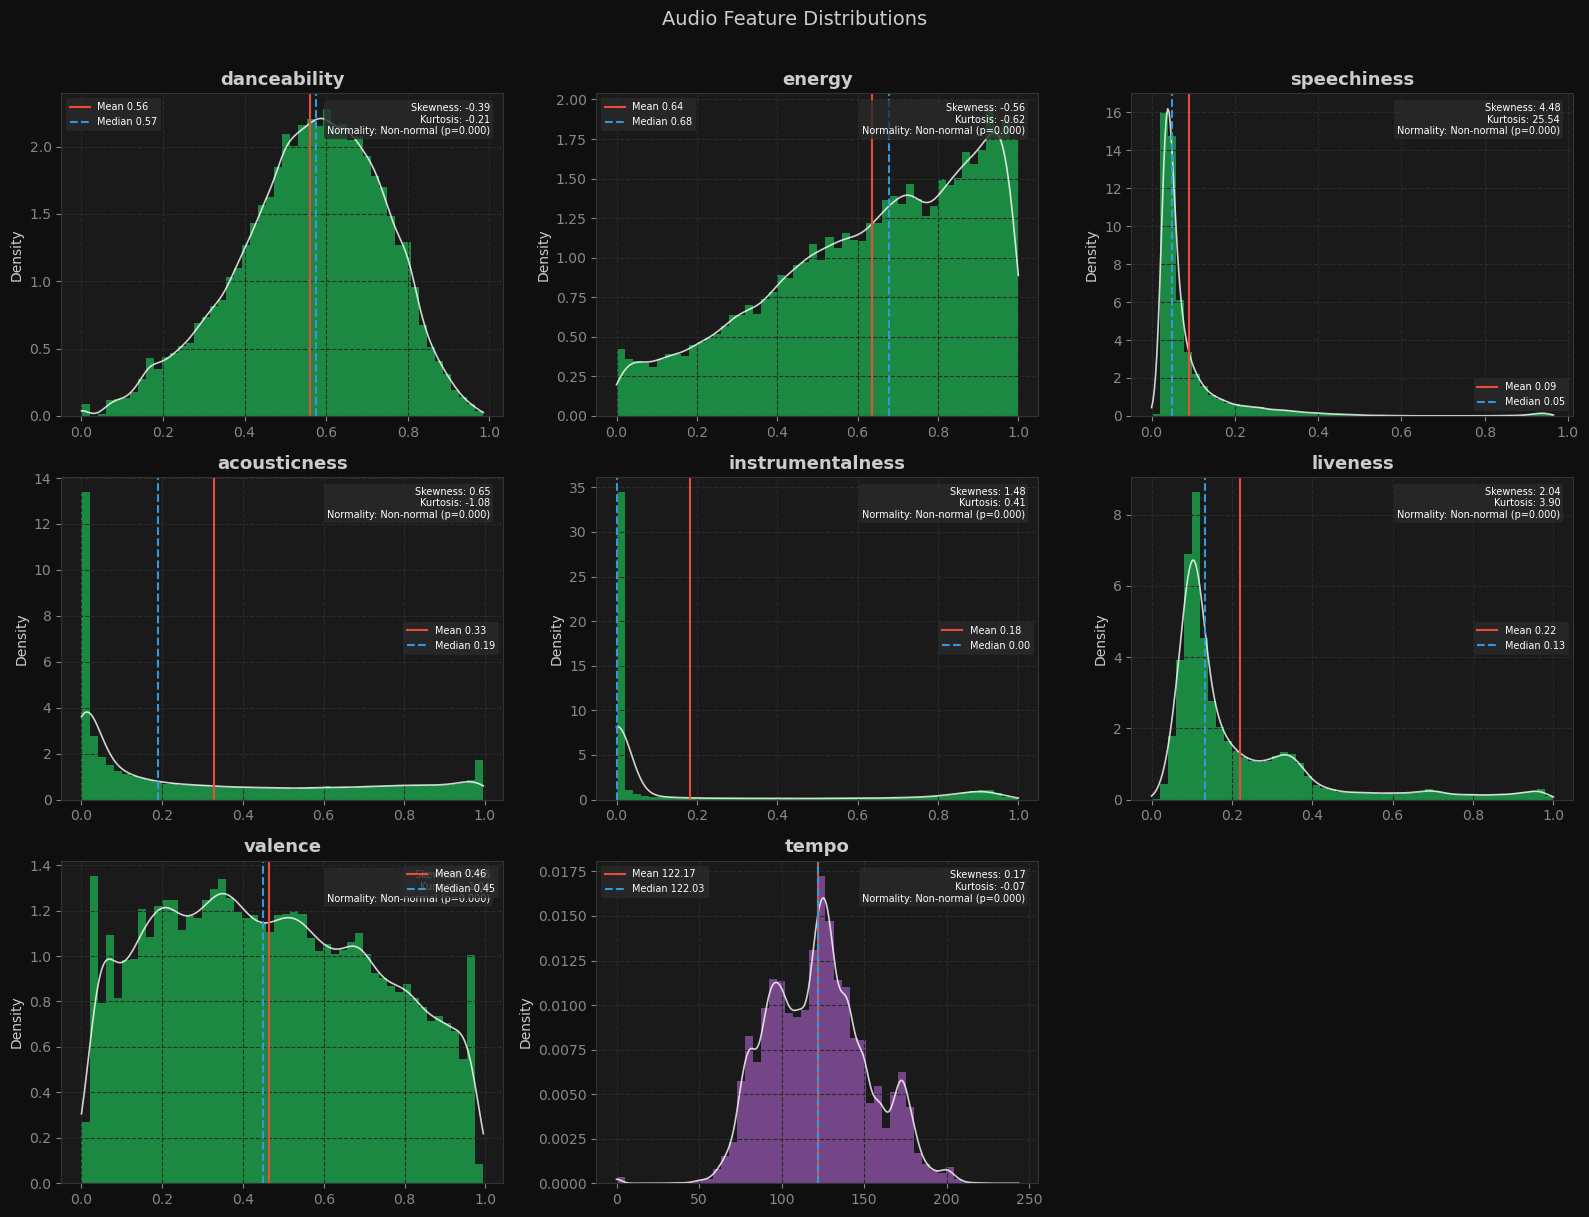

In [ ]:
# ───────────────── a. Audio feature distributions ─────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Audio Feature Distributions", fontsize=14, y=1.01)
axes = axes.flatten()

# Loop through each audio feature
for i, col in enumerate(all_plot_features):
    ax = axes[i]
    data = df_deduped[col].dropna()
    color = SPOTIFY_GREEN if col in audio_features else "#9B59B6"
    
    # Plot histogram with probability density scaling
    ax.hist(data, bins=50, color=color, alpha=0.7, edgecolor="none", density=True)

    # Generate KDE curve points
    kde_x = np.linspace(data.min(), data.max(), 300)

    ax.plot(kde_x, scipy_stats.gaussian_kde(data)(kde_x), color="white", lw=1.2, alpha=0.8)

    # Add mean, median, and other statistical reference lines
    add_stat_lines(ax, data)
    
    # Calculate skewness to measure distribution asymmetry
    skew = data.skew()

    # Calculate kurtosis to evaluate tail heaviness
    kurt = data.kurt()

    # Perform normality test using random sample
    _, p_norm = scipy_stats.normaltest(data.sample(min(5000, len(data)), random_state=42))
    normality = f"Non-normal (p={p_norm:.3f})" if p_norm < 0.05 else f"Normal (p={p_norm:.3f})"

    ax.text(
        0.97, 
        0.97, 
        f"Skewness: {skew:.2f}\nKurtosis: {kurt:.2f}\nNormality: {normality}",
        transform=ax.transAxes, 
        fontsize=7, 
        va="top", 
        ha="right", 
        color="white",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#2a2a2a", alpha=0.8, edgecolor="none")
        )
    
    ax.set_title(col)
    ax.set_ylabel("Density")
    ax.grid(True)
 
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()
plt.close()

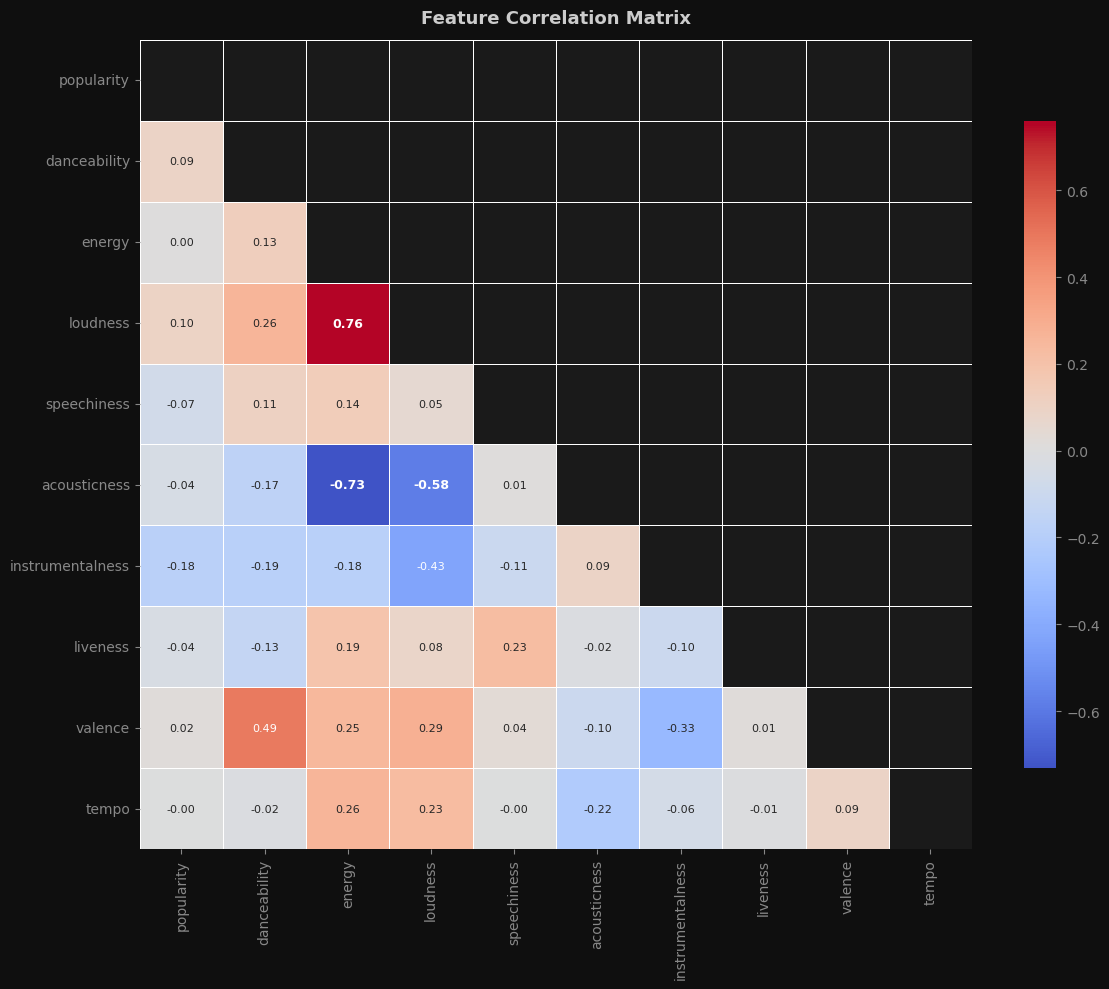

In [ ]:
# ───────────────── b. Correlation heatmap ─────────────────
fig, ax = plt.subplots(figsize=(12, 10))

# Calculate Pearson correlation matrix
corr = df_deduped[numeric_cols].corr()

# Create upper triangle mask to avoid duplicated information
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot correlation heatmap
sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",
    center=0, 
    linewidths=0.5, 
    ax=ax,
    annot_kws={"size": 8}, 
    cbar_kws={"shrink": 0.8}
    )

# Highlight strong correlations (|r| ≥ 0.5)
for text in ax.texts:
    try:
        if abs(float(text.get_text())) >= 0.5:
            text.set_fontweight("bold")
            text.set_fontsize(9)
    except ValueError:
        pass

ax.set_title("Feature Correlation Matrix", pad=12)
plt.tight_layout()
plt.show()
plt.close()

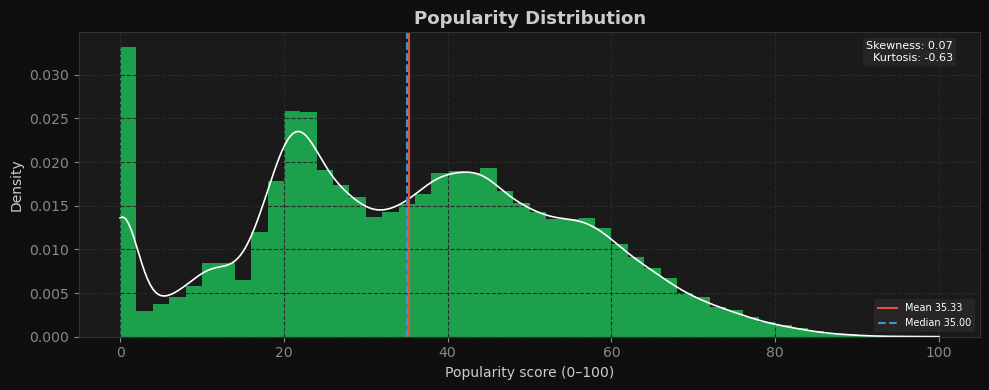

In [ ]:
# ───────────────── c. Popularity distribution ─────────────────
fig, ax = plt.subplots(figsize=(10, 4))

data = df_deduped["popularity"]

# Plot histogram with density normalization
ax.hist(
    data, 
    bins=50,
    color=SPOTIFY_GREEN, 
    alpha=0.85, 
    edgecolor="none",
    density=True
    )

# Generate x values for KDE curve
kde_x = np.linspace(data.min(), data.max(), 300)

# Overlay KDE curve
ax.plot(kde_x, scipy_stats.gaussian_kde(data)(kde_x), color="white", lw=1.2)

# Add statistical reference lines
add_stat_lines(ax, data)

ax.text(
    0.97, 
    0.97, 
    f"Skewness: {data.skew():.2f}\nKurtosis: {data.kurt():.2f}",
    transform=ax.transAxes, 
    fontsize=8, 
    va="top", 
    ha="right", 
    color="white",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#2a2a2a", alpha=0.8, edgecolor="none")
    )

ax.set_title("Popularity Distribution")
ax.set_xlabel("Popularity score (0–100)")
ax.set_ylabel("Density")
ax.grid(True)

plt.tight_layout()
plt.show()
plt.close()

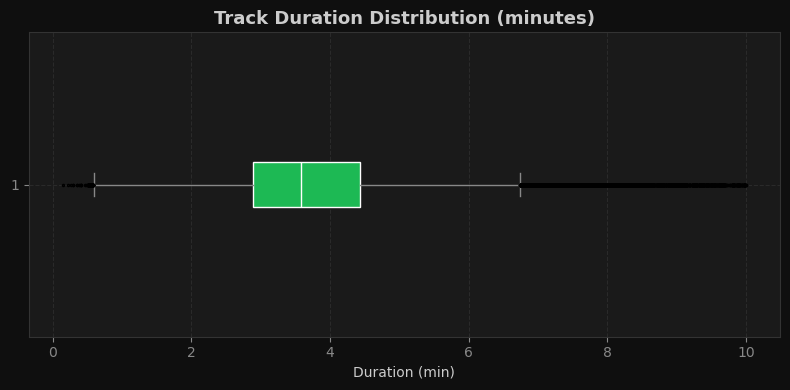

In [ ]:
# ───────────────── d. Duration boxplot ─────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.boxplot(
    df_deduped["duration_min"], 
    vert=False, 
    patch_artist=True,
    boxprops=dict(facecolor=SPOTIFY_GREEN, color="white"),
    medianprops=dict(color="white"),
    whiskerprops=dict(color="#888"),
    capprops=dict(color="#888"),
    flierprops=dict(marker=".", color="#555", markersize=3)
    )

ax.set_title("Track Duration Distribution (minutes)")
ax.set_xlabel("Duration (min)")
ax.grid(True)

plt.tight_layout()
plt.show()
plt.close()

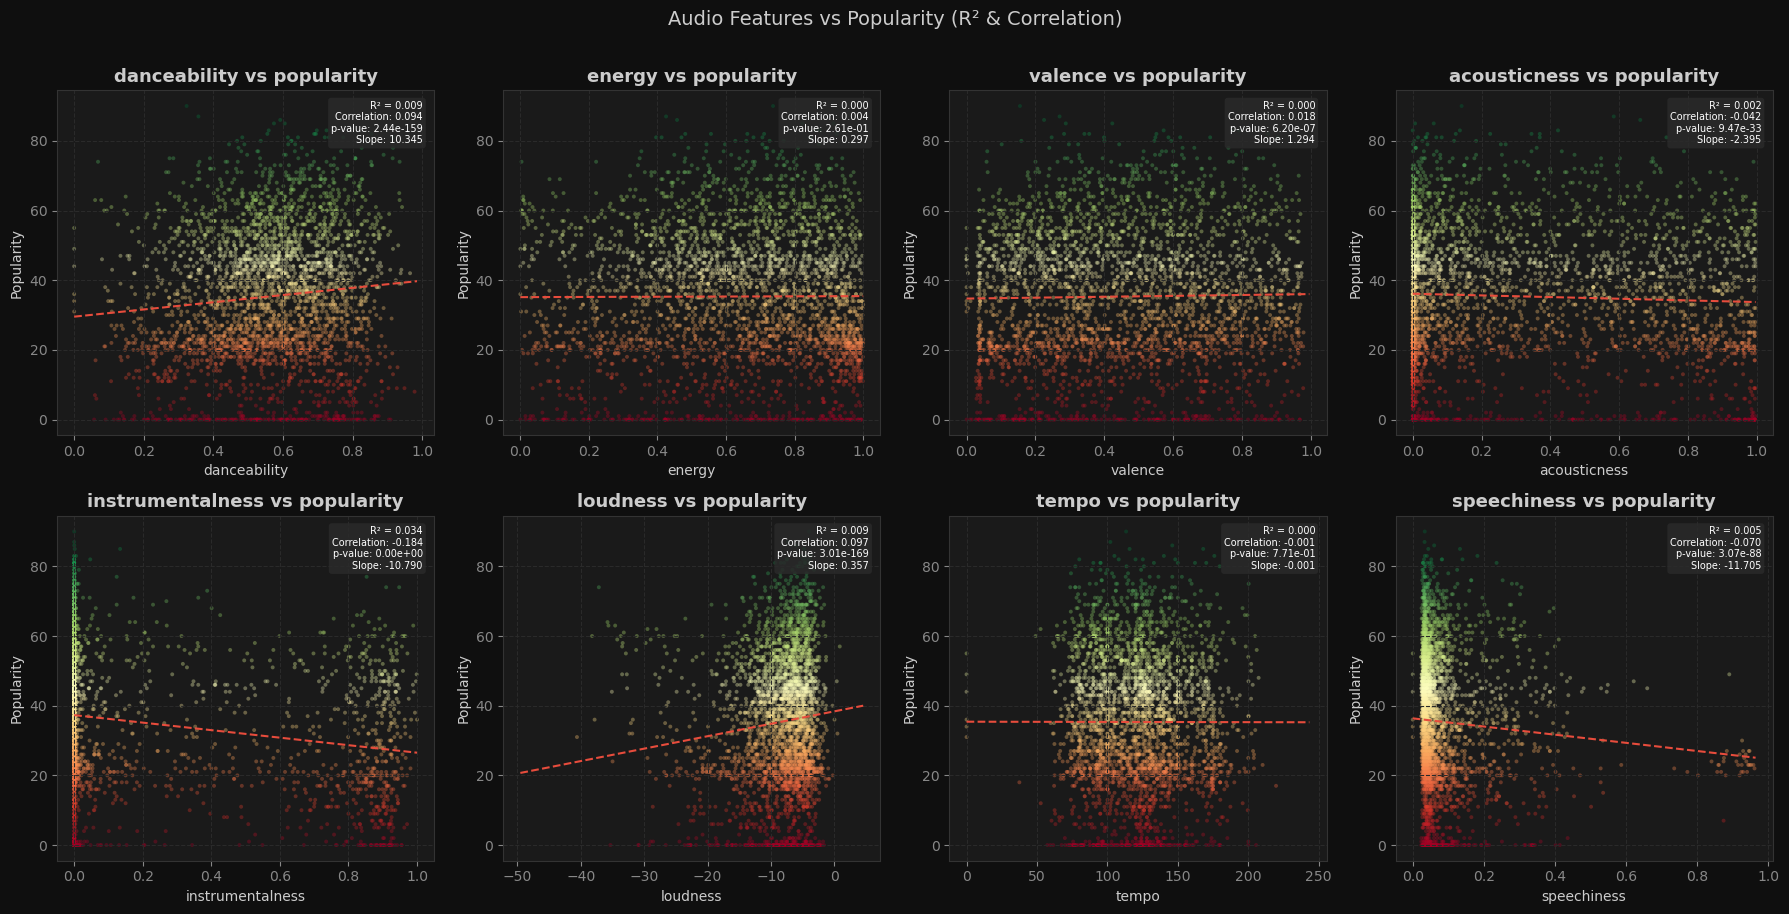

In [ ]:
# ───────────────── e. Scatter: feature vs popularity with R² ─────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Audio Features vs Popularity (R² & Correlation)",
             fontsize=14, y=1.01)
axes = axes.flatten()

scatter_features = ["danceability", "energy", "valence", "acousticness",
                    "instrumentalness", "loudness", "tempo", "speechiness"]

# Generate scatter plot for each feature
for i, feat in enumerate(scatter_features):
    ax = axes[i]

    # Select feature values and popularity scores
    x = df_deduped[feat]
    y = df_deduped["popularity"]

    sample = df_deduped[[feat, "popularity"]].dropna().sample(3000, random_state=42)

    ax.scatter(
        sample[feat], 
        sample["popularity"],
        c=sample["popularity"], 
        cmap="RdYlGn",
        alpha=0.35, 
        s=8, 
        edgecolors="none"
        )
    
    # Fit linear regression model
    slope, intercept, r, p_val, _ = scipy_stats.linregress(x.dropna(), y[x.notna()])
    
    # Generate regression line
    x_line = np.linspace(x.min(), x.max(), 200)

    ax.plot(
        x_line, 
        slope * x_line + intercept, 
        color="#E74C3C", 
        lw=1.5, 
        linestyle="--"
        )
    
    ax.text(
        0.97, 
        0.97,
        f"R² = {r**2:.3f}\nCorrelation: {r:.3f}\np-value: {p_val:.2e}\nSlope: {slope:.3f}",
        transform=ax.transAxes, 
        fontsize=7, 
        va="top", 
        ha="right", 
        color="white",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#2a2a2a", alpha=0.85, edgecolor="none")
        )
    
    ax.set_xlabel(feat)
    ax.set_ylabel("Popularity")
    ax.set_title(f"{feat} vs popularity")
    ax.grid(True)
 
plt.tight_layout()
plt.show()
plt.close()

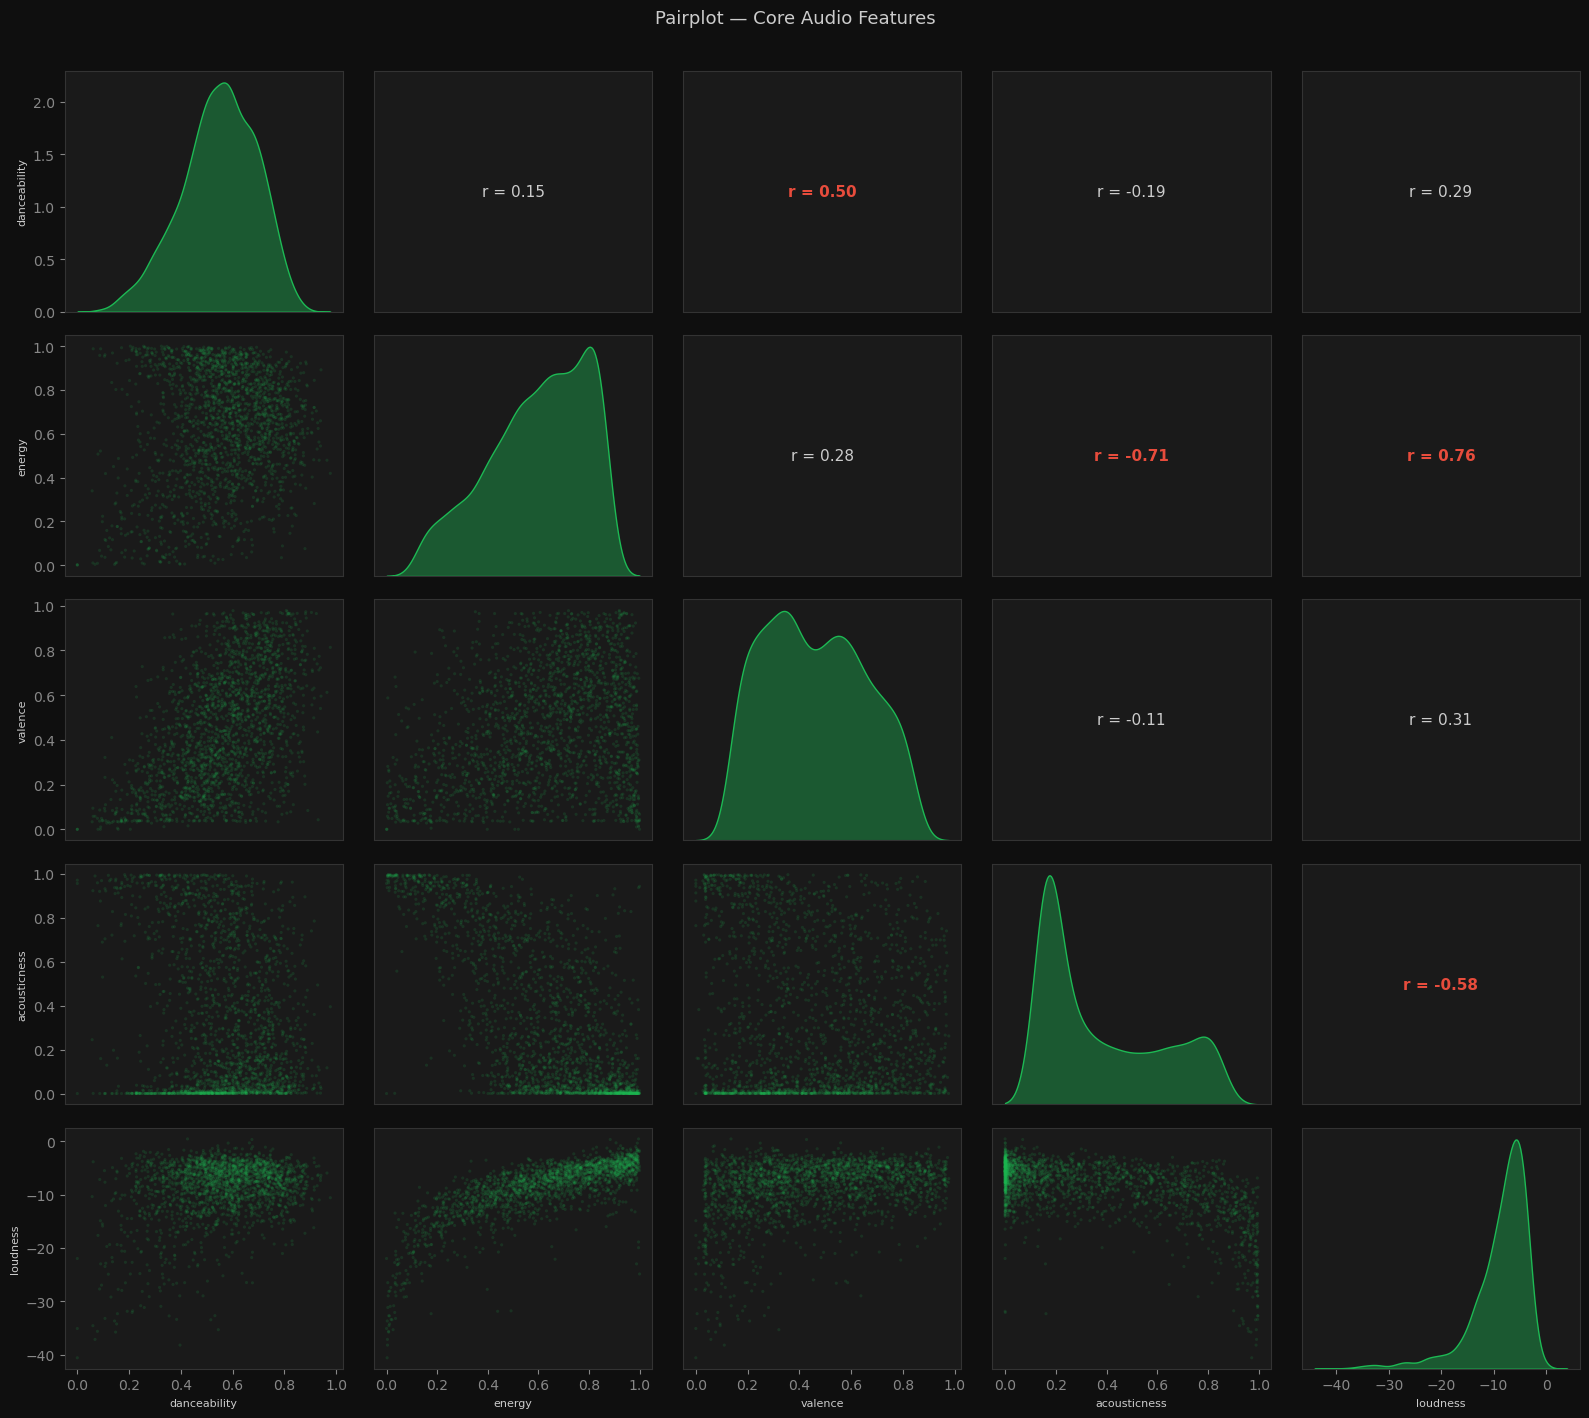

In [ ]:
# ───────────────── f. Pairplot of core audio features ─────────────────
pair_features = ["danceability", "energy", "valence", "acousticness", "loudness"]
pair_df = df_deduped[pair_features].dropna().sample(2000, random_state=42)
 
fig, axes = plt.subplots(
    len(pair_features), 
    len(pair_features), 
    figsize=(16, 14)
    )

fig.suptitle("Pairplot — Core Audio Features",
             fontsize=13, y=1.01)

# Loop through feature combinations
for i, col_i in enumerate(pair_features):
    for j, col_j in enumerate(pair_features):
        ax = axes[i][j]
        ax.set_facecolor("#1a1a1a")

        # Diagonal: show KDE distributions
        if i == j:
            sns.kdeplot(pair_df[col_i], ax=ax, color=SPOTIFY_GREEN, fill=True, alpha=0.4)

        # Upper triangle: display correlation values
        elif i < j:
            # Calculate Pearson correlation
            r, _ = scipy_stats.pearsonr(pair_df[col_i], pair_df[col_j])

            # Highlight strong correlations
            color = "#E74C3C" if abs(r) >= 0.5 else "#cccccc"

            ax.text(
                0.5, 
                0.5, 
                f"r = {r:.2f}", 
                transform=ax.transAxes,
                ha="center", 
                va="center", 
                fontsize=11, 
                color=color,
                fontweight="bold" if abs(r) >= 0.5 else "normal"
                )
            
            ax.set_xticks([])
            ax.set_yticks([])
        
        # Lower triangle: show scatter relationships
        else:
            ax.scatter(
                pair_df[col_j], 
                pair_df[col_i],
                alpha=0.15, 
                s=5, 
                color=SPOTIFY_GREEN, 
                edgecolors="none"
                )
            
        # Display y-axis labels only on first column
        if j == 0:
            ax.set_ylabel(col_i, fontsize=8)
        else:
            ax.set_ylabel(""); ax.set_yticks([])
        
        # Display x-axis labels only on bottom row
        if i == len(pair_features) - 1:
            ax.set_xlabel(col_j, fontsize=8)
        else:
            ax.set_xlabel(""); ax.set_xticks([])
            
        for spine in ax.spines.values():
            spine.set_edgecolor("#333333")
 
plt.tight_layout()
plt.show()
plt.close()

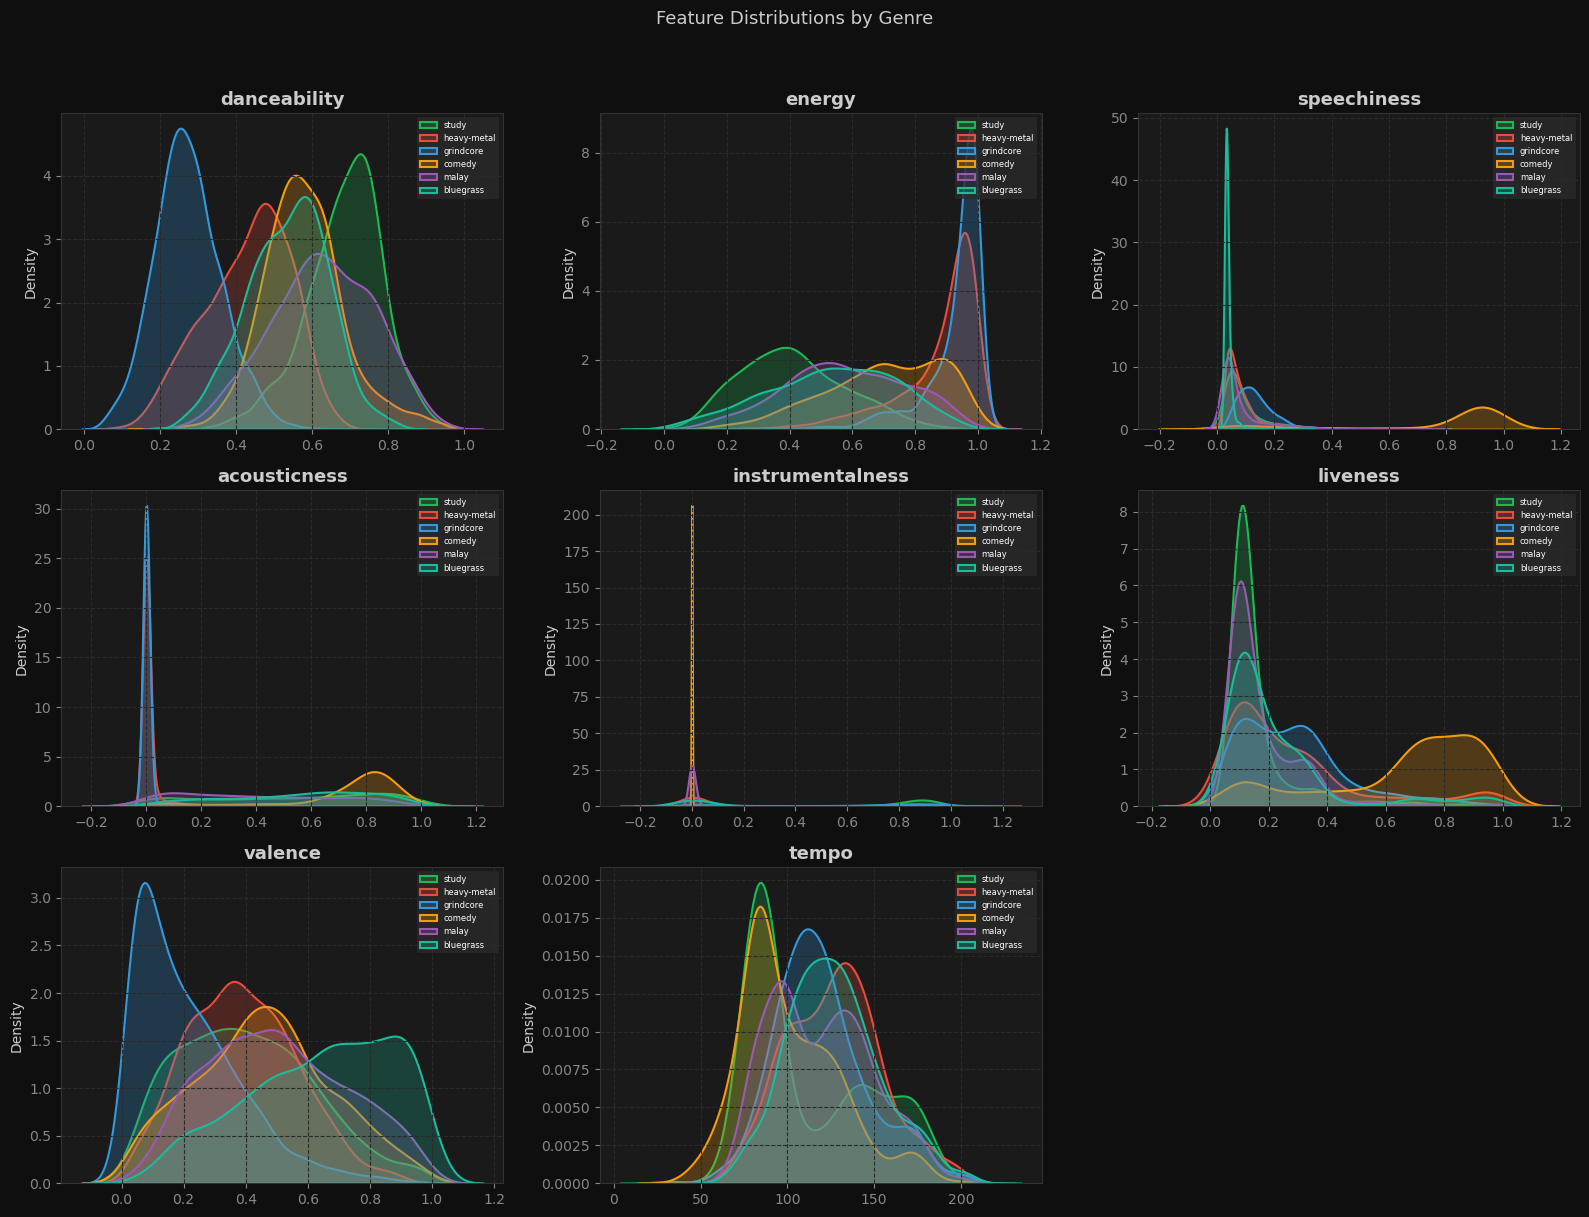

In [ ]:
# ────────────── g. Class-separated feature distributions by genre ──────────────
# Evaluate audio feature separability and identify features that may improve genre classification performance
df_top = df_deduped[df_deduped["track_genre"].isin(TOP_GENRES)]
 
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Feature Distributions by Genre\n",
             fontsize=13, y=1.01)
axes = axes.flatten()

# Loop through audio features
for i, feat in enumerate(all_plot_features):
    ax = axes[i]

    # Plot KDE curve for each genre
    for genre in TOP_GENRES:
        data = df_top[df_top["track_genre"] == genre][feat].dropna()
        sns.kdeplot(
            data, 
            ax=ax, 
            label=genre,
            color=genre_color_map[genre], 
            fill=True, 
            alpha=0.25, 
            linewidth=1.5
            )
        
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.set_ylabel("Density")
    ax.grid(True)
    ax.legend(fontsize=6, facecolor="#2a2a2a", edgecolor="none",
              labelcolor="white", loc="upper right")
 
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()
plt.close()

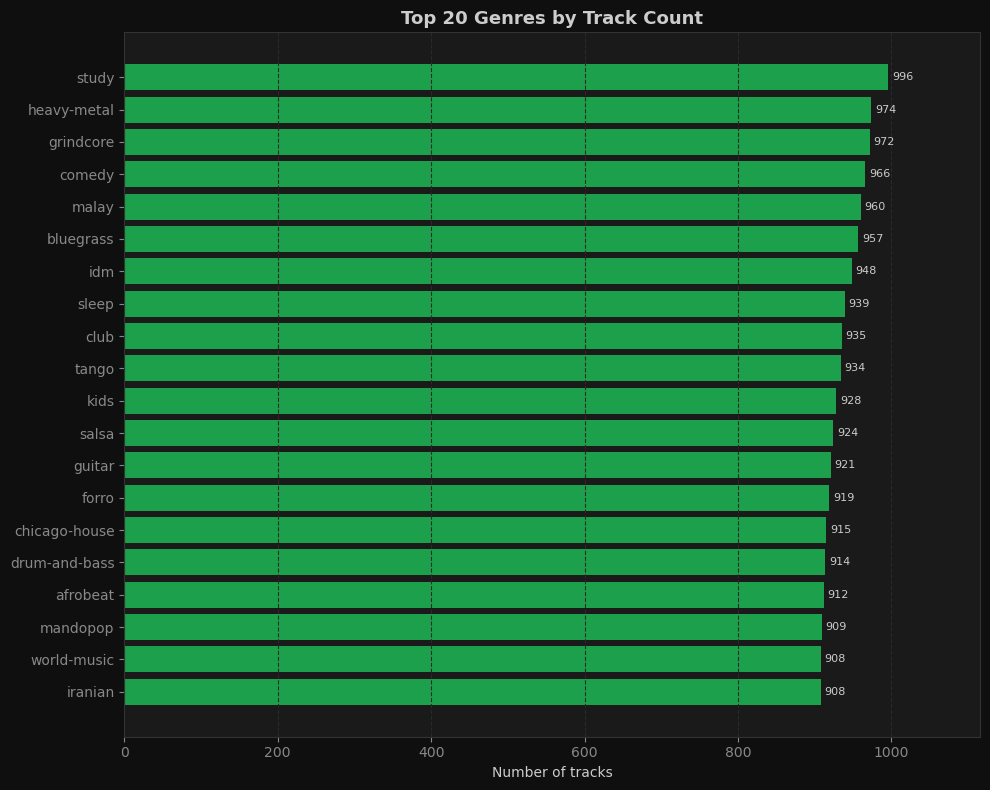

In [ ]:
# ────────────── h. Genre frequency analysis ──────────────
fig, ax = plt.subplots(figsize=(10, 8))

# Count number of tracks per genre
genre_counts = df_deduped["track_genre"].value_counts().head(20)

# Plot horizontal bar chart
bars = ax.barh(
    genre_counts.index[::-1], 
    genre_counts.values[::-1],
    color=SPOTIFY_GREEN, 
    alpha=0.85, 
    edgecolor="none"
    )

for bar, val in zip(bars, genre_counts.values[::-1]):
    ax.text(
        bar.get_width() + 5, 
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}", 
        va="center", 
        fontsize=8, 
        color="#cccccc"
        )
    
ax.set_title("Top 20 Genres by Track Count")
ax.set_xlabel("Number of tracks")
ax.grid(True, axis="x")
ax.set_xlim(0, genre_counts.max() * 1.12)
plt.tight_layout()
plt.show()
plt.close()

<h4>Section 4: Vibe Label Engineering</h4>

**STEP 1: SELECT & SCALE CLUSTERING FEATURES**

In [23]:
# ────────────── Features chosen based on EDA findings ──────────────
# energy, danceability → best class-separating features
# valence, tempo       → moderate separation
# acousticness         → moderate (correlated with energy/loudness but conceptually distinct)
# speechiness          → useful for speech-heavy vibes
# liveness             → useful for live/performance vibes
# instrumentalness     → low genre separation but conceptually meaningful
# Excluded: loudness (r=0.77 with energy)
#           popularity (R²<0.01 vs all features)
 
CLUSTER_FEATURES = [
    "danceability", "energy", "valence", "tempo",
    "acousticness", "speechiness", "liveness", "instrumentalness",
]

In [26]:
print(f"Clustering Features: ")

for f in CLUSTER_FEATURES:
    print(f"- {f}")
 
X_raw = df_deduped[CLUSTER_FEATURES].copy()
 
# Scale to [0, 1] so all features contribute equally
cluster_scaler = MinMaxScaler()
X = cluster_scaler.fit_transform(X_raw)
 
print(f"\nScaled {len(CLUSTER_FEATURES)} features to [0, 1] for clustering.")

Clustering Features: 
- danceability
- energy
- valence
- tempo
- acousticness
- speechiness
- liveness
- instrumentalness

Scaled 8 features to [0, 1] for clustering.


**STEP 2: FIND OPTIMAL K**

k= 2  inertia=26,873  silhouette=0.3044  DB=1.4231
k= 3  inertia=21,514  silhouette=0.2885  DB=1.2983
k= 4  inertia=17,740  silhouette=0.3164  DB=1.1809
k= 5  inertia=15,392  silhouette=0.2533  DB=1.2853
k= 6  inertia=13,946  silhouette=0.2645  DB=1.2316
k= 7  inertia=12,881  silhouette=0.2447  DB=1.2601
k= 8  inertia=12,132  silhouette=0.2391  DB=1.2544
k= 9  inertia=11,481  silhouette=0.2469  DB=1.1865
k=10  inertia=10,917  silhouette=0.2369  DB=1.2888
k=11  inertia=10,550  silhouette=0.2262  DB=1.3628
k=12  inertia=10,194  silhouette=0.1974  DB=1.4318

Best k by Silhouette: 4
Best k by Davies-Bouldin: 4


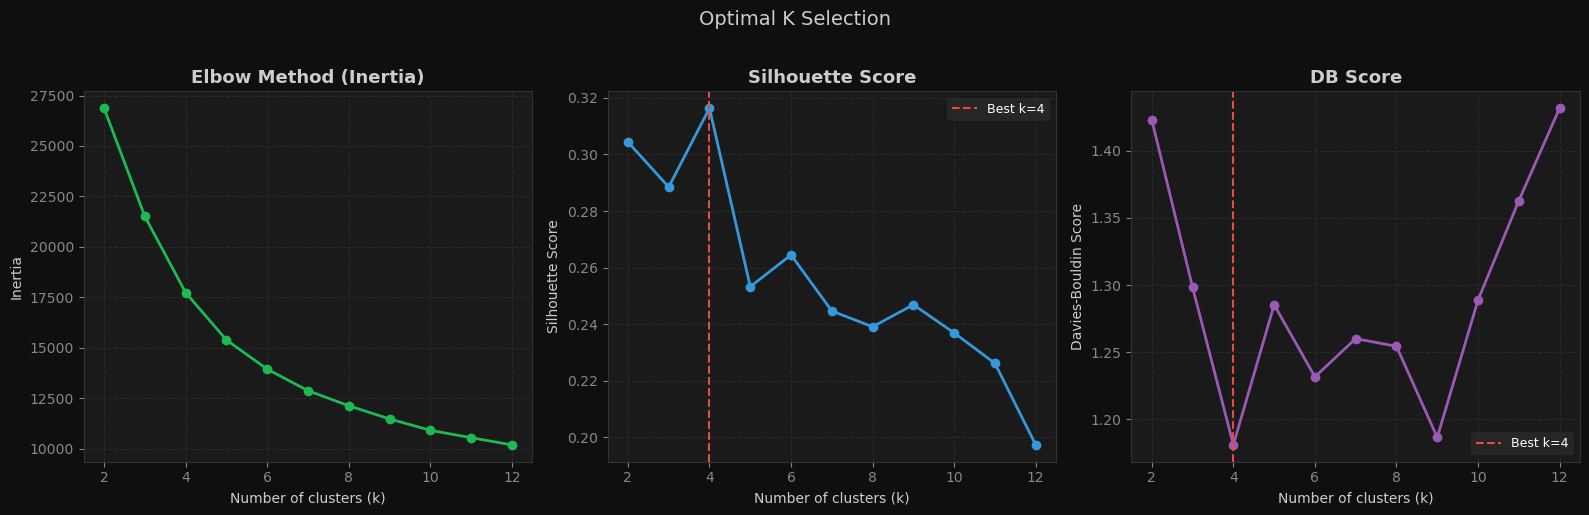

In [27]:
k_range = range(2, 13)

inertias = []
silhouettes = []
db_scores = []
 
# Randomly sample data to speed up silhouette and DB score calculation
np.random.seed(42)

sample_idx = np.random.choice(len(X), size=8000, replace=False)
X_sample = X[sample_idx]
 
# Train and evaluate K-Means models for each k value
for k in k_range:

    # Initialize K-Means model
    km = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Fit K-Means and assign cluster labels
    labels_full = km.fit_predict(X)

    # Extract labels for sampled data
    labels_sample = labels_full[sample_idx]

    inertias.append(km.inertia_)                                        # Store inertia score
    silhouettes.append(silhouette_score(X_sample, labels_sample))       # Store silhouette score
    db_scores.append(davies_bouldin_score(X_sample, labels_sample))     # Store Davies-Bouldin score

    print(f"k={k:2d}  inertia={km.inertia_:,.0f}  silhouette={silhouettes[-1]:.4f}  DB={db_scores[-1]:.4f}")
          
k_list = list(k_range)
best_sil_k = k_list[np.argmax(silhouettes)]   # Select k with highest silhouette score
best_db_k = k_list[np.argmin(db_scores)]      # Select k with lowest Davies-Bouldin score
 
print(f"\nBest k by Silhouette: {best_sil_k}")
print(f"Best k by Davies-Bouldin: {best_db_k}")
 
# ────────────── Plot clustering evaluation metrics ──────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Optimal K Selection", fontsize=14, y=1.02)

# Plot elbow method using inertia
axes[0].plot(
    k_list, 
    inertias, 
    "o-", 
    color=SPOTIFY_GREEN, 
    lw=2, 
    markersize=6
    )
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True)

# Plot silhouette scores
axes[1].plot(
    k_list, 
    silhouettes, 
    "o-", 
    color="#3498DB", 
    lw=2, 
    markersize=6
    )
axes[1].axvline(best_sil_k, color="#E74C3C", lw=1.5, linestyle="--", label=f"Best k={best_sil_k}")  # Mark best k based on silhouette score
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend(fontsize=9, facecolor="#2a2a2a", edgecolor="none", labelcolor="white")
axes[1].grid(True)

# Plot DB scores
axes[2].plot(
    k_list,
    db_scores, 
    "o-", 
    color="#9B59B6", 
    lw=2, 
    markersize=6
    )
axes[2].axvline(best_db_k, color="#E74C3C", lw=1.5, linestyle="--", label=f"Best k={best_db_k}")   # Mark best k based on DB score
axes[2].set_title("DB Score")
axes[2].set_xlabel("Number of clusters (k)")
axes[2].set_ylabel("Davies-Bouldin Score")
axes[2].legend(fontsize=9, facecolor="#2a2a2a", edgecolor="none", labelcolor="white")
axes[2].grid(True)
 
plt.tight_layout()
plt.show()
plt.close()

**STEP 3: FIT FINAL K-MEANS**

In [28]:
K = 4
 
kmeans = KMeans(n_clusters=K, random_state=42, n_init=20)

# Fit model and assign cluster labels
df_deduped["cluster"] = kmeans.fit_predict(X)

# Count number of tracks in each cluster
cluster_counts = df_deduped["cluster"].value_counts().sort_index()

print("\nCluster sizes:")
for c, count in cluster_counts.items():
    print(f"   Cluster {c}: {count:,} tracks ({count/len(df_deduped)*100:.1f}%)")


Cluster sizes:
   Cluster 0: 21,940 tracks (27.2%)
   Cluster 1: 10,381 tracks (12.8%)
   Cluster 2: 41,885 tracks (51.8%)
   Cluster 3: 6,594 tracks (8.2%)


**STEP 4: INTERPRET & NAME CLUSTERS**

In [30]:
# Convert centroids back to original feature scale
centroids_raw = pd.DataFrame(
    cluster_scaler.inverse_transform(kmeans.cluster_centers_),
    columns=CLUSTER_FEATURES,
    index=range(K)
)

centroids_raw.index.name = "cluster"

print("Cluster Centroids (Original Scale):")
print(centroids_raw.round(3).to_string())

Cluster Centroids (Original Scale):
         danceability  energy  valence    tempo  acousticness  speechiness  liveness  instrumentalness
cluster                                                                                               
0               0.550   0.444    0.462  115.671         0.699        0.099     0.231             0.017
1               0.557   0.770    0.336  127.496         0.068        0.075     0.202             0.766
2               0.592   0.769    0.535  126.736         0.116        0.092     0.227             0.021
3               0.400   0.215    0.228  106.416         0.862        0.054     0.157             0.848


In [32]:
# Compare each centroid against overall dataset averages (positive = above average, negative = below average)
overall_means = df_deduped[CLUSTER_FEATURES].mean()

cluster_compare = centroids_raw.copy()

for col in CLUSTER_FEATURES:
    cluster_compare[col] = (centroids_raw[col] - overall_means[col]).round(3)

print("Centroid Difference vs Dataset Mean:")
print(cluster_compare.to_string())

Centroid Difference vs Dataset Mean:
         danceability  energy  valence   tempo  acousticness  speechiness  liveness  instrumentalness
cluster                                                                                              
0              -0.010  -0.192   -0.002  -6.500         0.370        0.010     0.012            -0.166
1              -0.003   0.134   -0.129   5.326        -0.261       -0.014    -0.018             0.583
2               0.031   0.134    0.070   4.565        -0.213        0.004     0.008            -0.162
3              -0.161  -0.421   -0.237 -15.754         0.533       -0.035    -0.062             0.665


In [34]:
# Show sample songs from each cluster
sample_cols = ["track_name", "artists", "track_genre", "popularity"] + CLUSTER_FEATURES

for c in range(K):
    print(f"Cluster {c} — sample songs:")
    
    cluster_sample = (
        df_deduped[df_deduped["cluster"] == c][sample_cols]
        .sample(min(5, (df_deduped["cluster"] == c).sum()), random_state=42)
        .reset_index(drop=True)
    )
    
    print(cluster_sample.round(3).to_string(index=False))

Cluster 0 — sample songs:
                      track_name                    artists track_genre  popularity  danceability  energy  valence   tempo  acousticness  speechiness  liveness  instrumentalness
                  You Are Loving     Timmies;Shiloh Dynasty         sad          57         0.814   0.333    0.387  99.994         0.874        0.189     0.615               0.0
                  Alguém Como Eu               Luiz Arcanjo      groove          28         0.511   0.198    0.261 128.312         0.897        0.033     0.131               0.0
                   One More Time                  Ray Price  honky-tonk          11         0.440   0.523    0.686  64.099         0.863        0.048     0.086               0.0
(Evil Hearted Me) Downright Evil              Jody Reynolds  rockabilly          23         0.593   0.865    0.969 157.960         0.719        0.038     0.303               0.0
                     Pehla Pyaar Armaan Malik;Vishal Mishra    pop-film          76 

In [38]:
# ────────────────────────── Rules derived from k=4 centroid patterns ──────────────────────────
# Acoustic & Mellow       → high acousticness (>0.5), low energy (<0.5), low instrumental
# Instrumental            → high instrumentalness (>0.5), high energy, low acousticness
# Energetic & Danceable   → high energy (>0.7), high danceability (>0.55), high valence (>0.5)
# Acoustic & Instrumental → high instrumentalness (>0.5), high acousticness (>0.5), low energy

vibe_names = {}

# Loop through each cluster centroid
for c in range(K):
    row = centroids_raw.loc[c]

    # Acoustic + instrumental cluster
    if row["acousticness"] > 0.5 and row["instrumentalness"] > 0.5:
        vibe_names[c] = "Acoustic & Instrumental"

    # Instrumental-focused cluster   
    elif row["instrumentalness"] > 0.5:
        vibe_names[c] = "Instrumental"

    # Relaxed acoustic cluster
    elif row["acousticness"] > 0.5 and row["energy"] < 0.5:
        vibe_names[c] = "Acoustic & Mellow"

    # High-energy dance cluster
    elif row["energy"] > 0.7 and row["danceability"] > 0.55 and row["valence"] > 0.5:
        vibe_names[c] = "Energetic & Danceable"

    else:
        vibe_names[c] = f"Mixed (cluster {c})"
 
print("──────────────────────── Vibe Label Assignments ────────────────────────")
for c, name in vibe_names.items():
    row = centroids_raw.loc[c]

    print(f"Cluster {c} → '{name}'")
    print(f"    energy={row['energy']:.2f}  dance={row['danceability']:.2f}  "
          f"valence={row['valence']:.2f}  acoustic={row['acousticness']:.2f}  "
          f"speech={row['speechiness']:.2f}  instrumental={row['instrumentalness']:.2f}")
 
df_deduped["vibe"] = df_deduped["cluster"].map(vibe_names)
 
print("\n────────────────────────── Vibe Distribution ──────────────────────────")
vibe_counts = df_deduped["vibe"].value_counts()
for vibe, count in vibe_counts.items():
    print(f"{vibe:<28}: {count:,} ({count/len(df_deduped)*100:.1f}%)")

──────────────────────── Vibe Label Assignments ────────────────────────
Cluster 0 → 'Acoustic & Mellow'
    energy=0.44  dance=0.55  valence=0.46  acoustic=0.70  speech=0.10  instrumental=0.02
Cluster 1 → 'Instrumental'
    energy=0.77  dance=0.56  valence=0.34  acoustic=0.07  speech=0.08  instrumental=0.77
Cluster 2 → 'Energetic & Danceable'
    energy=0.77  dance=0.59  valence=0.53  acoustic=0.12  speech=0.09  instrumental=0.02
Cluster 3 → 'Acoustic & Instrumental'
    energy=0.22  dance=0.40  valence=0.23  acoustic=0.86  speech=0.05  instrumental=0.85

────────────────────────── Vibe Distribution ──────────────────────────
Energetic & Danceable       : 41,885 (51.8%)
Acoustic & Mellow           : 21,940 (27.2%)
Instrumental                : 10,381 (12.8%)
Acoustic & Instrumental     : 6,594 (8.2%)


**STEP 5: CLUSTER VISUALIZATIONS**

In [40]:
VIBE_COLORS = [
    "#1DB954", "#E74C3C", "#3498DB",
    "#F39C12", "#9B59B6", "#1ABC9C",
]

color_map = {name: VIBE_COLORS[i % len(VIBE_COLORS)]
             for i, name in enumerate(sorted(df_deduped["vibe"].unique()))}

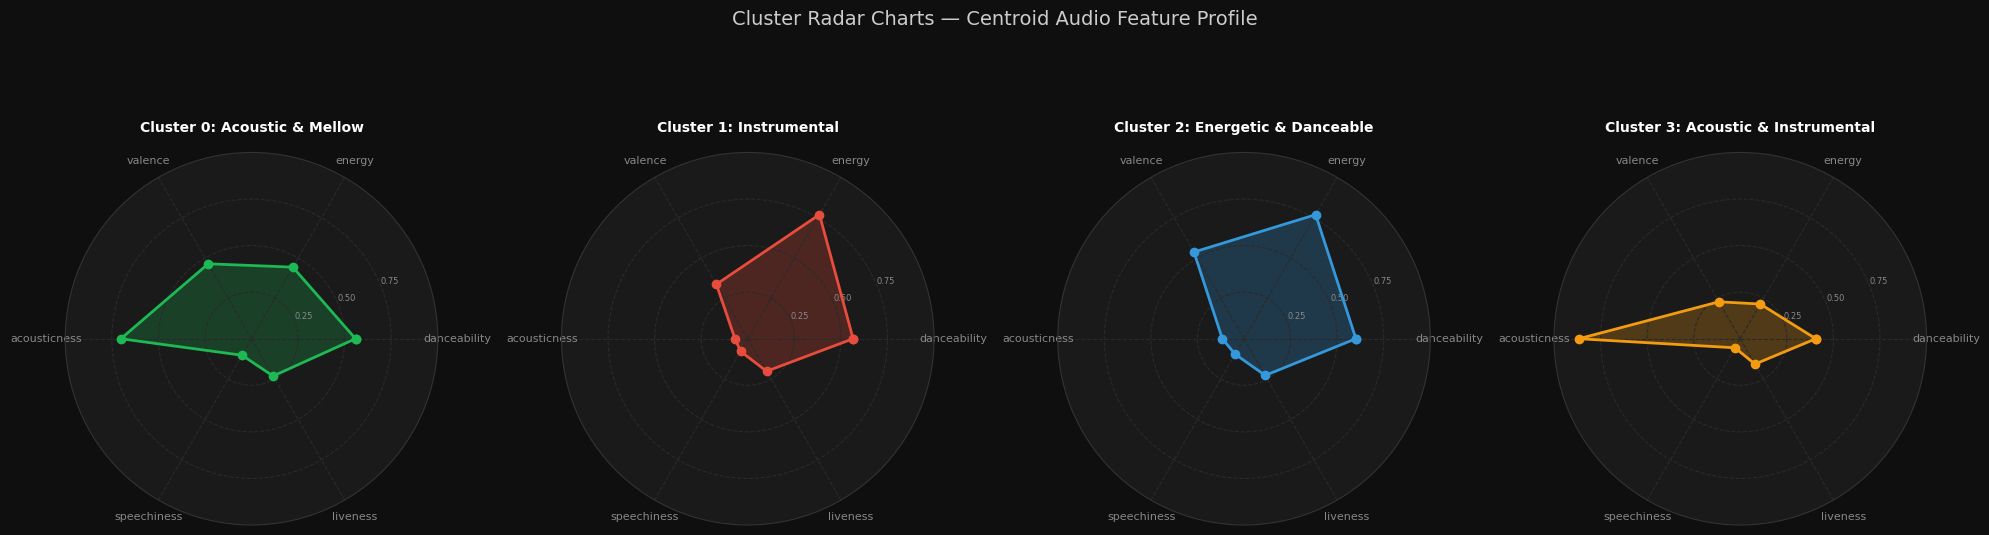

In [42]:
# ────────────── a. Radar charts ──────────────
# Visualize centroid profiles for each cluster to compare audio feature patterns and interpret vibe characteristics 
features_radar = ["danceability", "energy", "valence",
                  "acousticness", "speechiness", "liveness"]

N = len(features_radar)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

centroids_scaled = pd.DataFrame(
    kmeans.cluster_centers_, columns=CLUSTER_FEATURES
    )[features_radar]
 
fig, axes = plt.subplots(1, 4, figsize=(20, 6), subplot_kw=dict(polar=True))
fig.suptitle("Cluster Radar Charts — Centroid Audio Feature Profile",
             fontsize=14, y=1.02)

# Create radar chart for each cluster
for i, (c, name) in enumerate(vibe_names.items()):
    ax = axes[i]
    values = centroids_scaled.loc[c, features_radar].tolist()
    values += values[:1]
    color = VIBE_COLORS[i % len(VIBE_COLORS)]

    ax.plot(
        angles, 
        values, 
        "o-", 
        color=color, 
        lw=2
        )
    
    ax.fill(angles, values, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features_radar, size=8, color="white")
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(["0.25", "0.50", "0.75"], size=6, color="#666")
    ax.set_facecolor("#1a1a1a")
    ax.tick_params(colors="#888")
    ax.spines["polar"].set_color("#333")
    ax.set_title(f"Cluster {c}: {name}", pad=15, color="white", size=10)
 
plt.tight_layout()
plt.show()
plt.close()

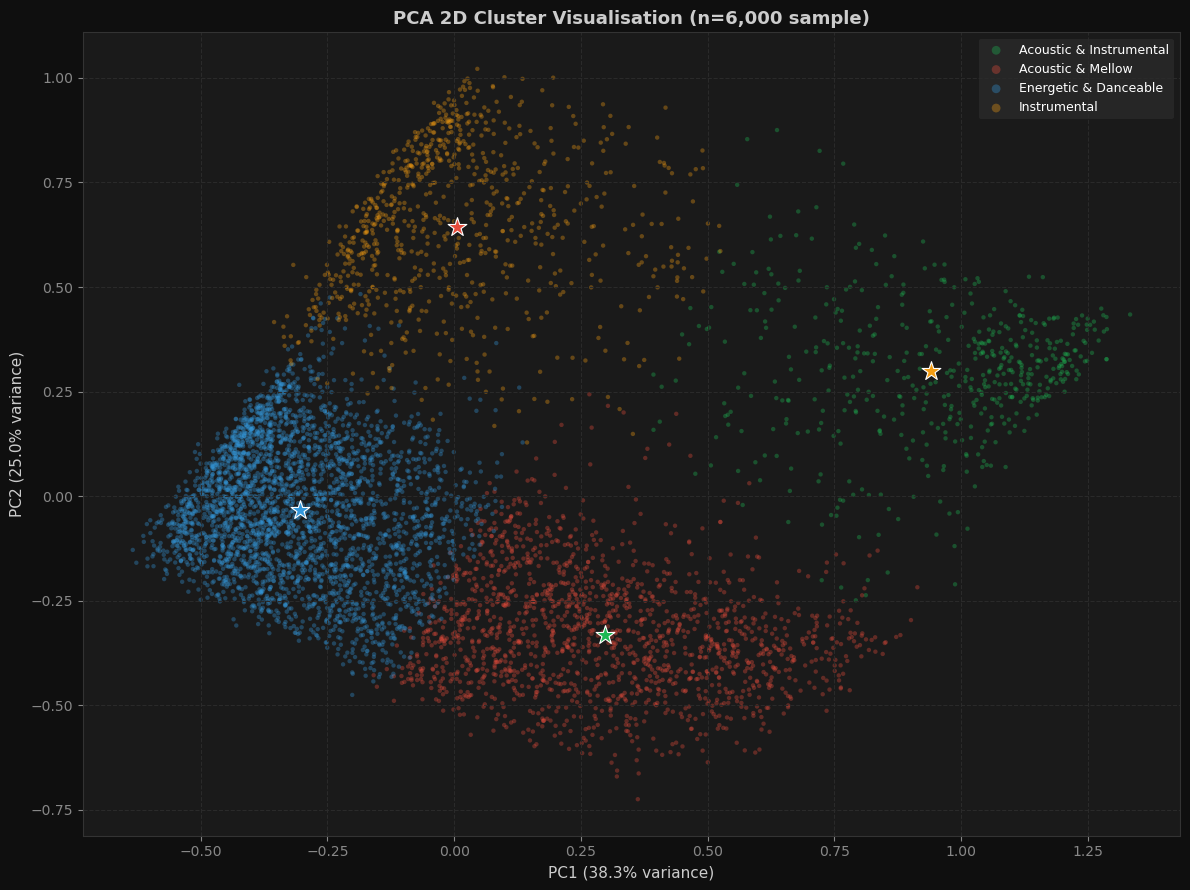

In [43]:
# ────────────── b. PCA 2D scatter ──────────────
# Reduce high-dimensional audio features into two principal components and visualize cluster separation in 2D space

# Initialize PCA model with two components
pca = PCA(n_components=2, random_state=42)

# Transform feature space into PCA coordinates
X_pca = pca.fit_transform(X)

var_explained = pca.explained_variance_ratio_

sample_n = 6000
idx = np.random.choice(len(X_pca), size=sample_n, replace=False)

pca_df = pd.DataFrame({
    "PC1": X_pca[idx, 0],
    "PC2": X_pca[idx, 1],
    "vibe": df_deduped["vibe"].iloc[idx].values,
})
 
fig, ax = plt.subplots(figsize=(12, 9))

# Plot each vibe group in PCA space
for vibe, grp in pca_df.groupby("vibe"):
    ax.scatter(
        grp["PC1"], 
        grp["PC2"], 
        label=vibe, 
        color=color_map[vibe],
        alpha=0.35, 
        s=10, 
        edgecolors="none"
        )
    
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Plot cluster centers
for i, (c, name) in enumerate(vibe_names.items()):
    ax.scatter(
        centroids_pca[i, 0], 
        centroids_pca[i, 1],
        color=VIBE_COLORS[i % len(VIBE_COLORS)],
        s=200, 
        marker="*", 
        edgecolors="white", 
        linewidths=0.8, 
        zorder=5
        )
    
ax.set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% variance)", fontsize=11)
ax.set_title(f"PCA 2D Cluster Visualisation (n={sample_n:,} sample)",
             fontsize=13)
ax.legend(fontsize=9, facecolor="#2a2a2a", edgecolor="none",
          labelcolor="white", markerscale=2, loc="upper right")
ax.grid(True)

plt.tight_layout()
plt.show()
plt.close()

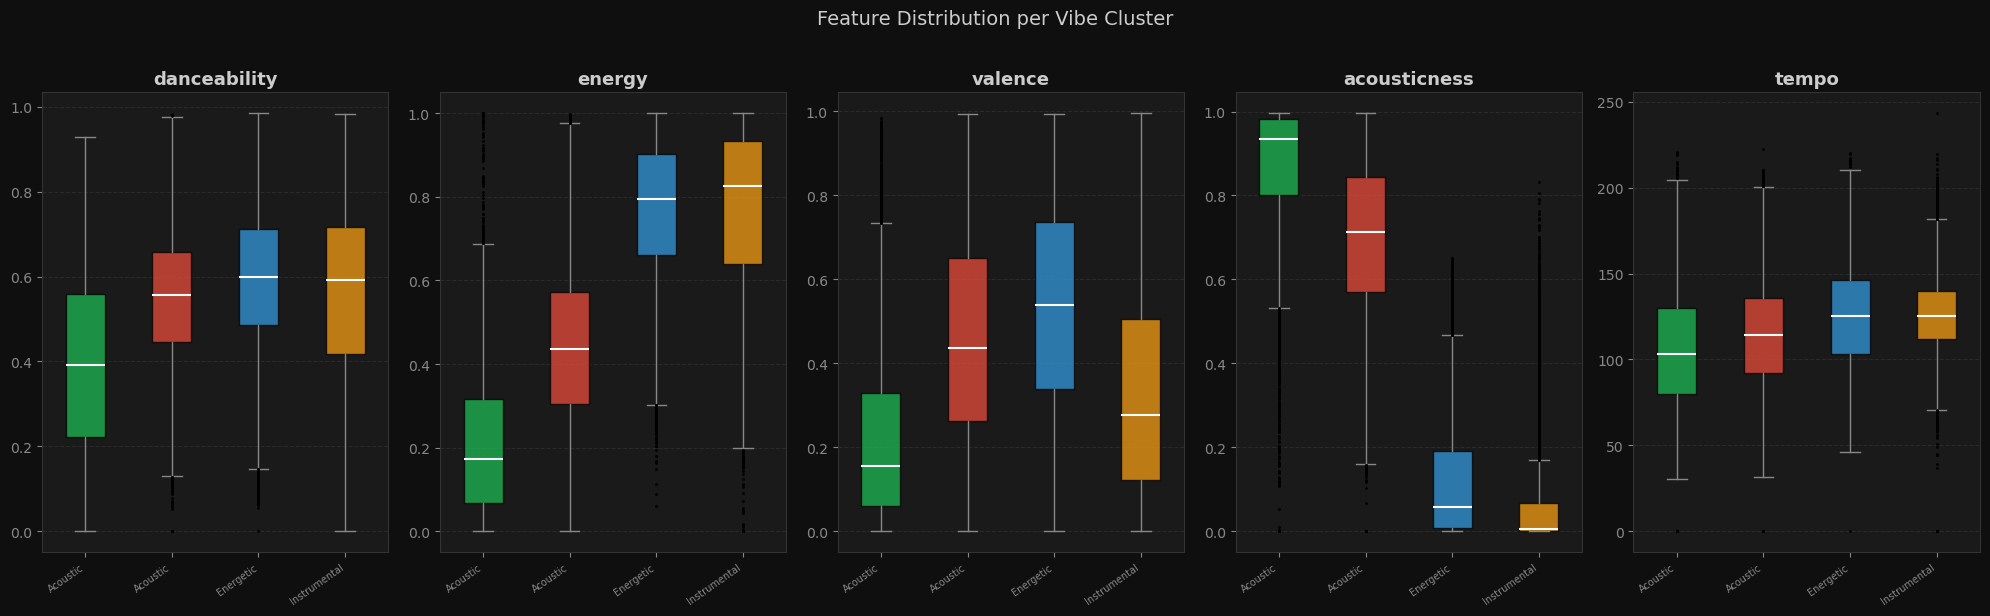

In [44]:
# ────────────── c. Boxplots per vibe cluster ──────────────
# Compare audio feature distributions across vibe groups to evaluate differences in median values, spread, and outliers
plot_features = ["danceability", "energy", "valence", "acousticness", "tempo"]

fig, axes = plt.subplots(1, len(plot_features), figsize=(20, 6))
fig.suptitle("Feature Distribution per Vibe Cluster", fontsize=14, y=1.02)

vibe_order = sorted(df_deduped["vibe"].unique())
palette = {v: color_map[v] for v in vibe_order}

# Generate boxplot for each feature
for i, feat in enumerate(plot_features):
    ax = axes[i]
    data_per_vibe = [df_deduped[df_deduped["vibe"] == v][feat].values for v in vibe_order]
    bp = ax.boxplot(
        data_per_vibe, 
        patch_artist=True, 
        vert=True,
        medianprops=dict(color="white", lw=1.5),                    # Median line style
        whiskerprops=dict(color="#888"),                            # Whisker style
        capprops=dict(color="#888"),                                # Cap style
        flierprops=dict(marker=".", color="#444", markersize=2)     # Outlier marker style
        )
    
    for patch, vibe in zip(bp["boxes"], vibe_order):
        patch.set_facecolor(palette[vibe]); patch.set_alpha(0.75)
        
    ax.set_title(feat)
    ax.set_xticks(range(1, len(vibe_order) + 1))
    ax.set_xticklabels([v.split(" ")[0] for v in vibe_order],
                       rotation=35, ha="right", fontsize=7)
    ax.grid(True, axis="y")
 
plt.tight_layout()
plt.show()
plt.close()

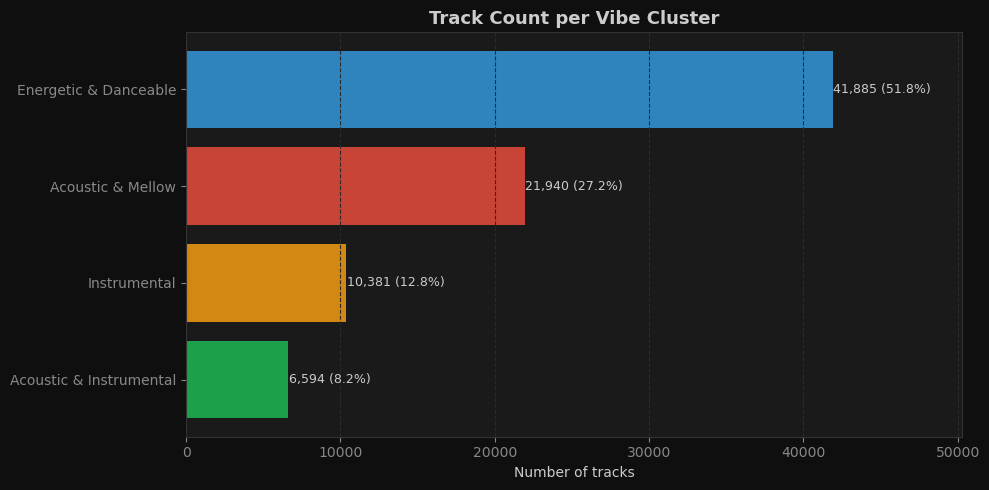

In [45]:
# ────────────── d. Vibe cluster size bar chart ──────────────
# Visualize the number of tracks assigned to each vibe group and evaluate cluster balance
fig, ax = plt.subplots(figsize=(10, 5))

vibes = vibe_counts.index.tolist()
counts = vibe_counts.values         # Extract track counts
colors = [color_map[v] for v in vibes]

bars = ax.barh(
    vibes[::-1], 
    counts[::-1], 
    color=colors[::-1],
    alpha=0.85, 
    edgecolor="none"
    )

# Display count and percentage labels
for bar, val in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f"{val:,} ({val/len(df_deduped)*100:.1f}%)",
            va="center", fontsize=9, color="#cccccc")
    
ax.set_title("Track Count per Vibe Cluster")
ax.set_xlabel("Number of tracks")
ax.set_xlim(0, max(counts) * 1.2)
ax.grid(True, axis="x")

plt.tight_layout()
plt.show()
plt.close()

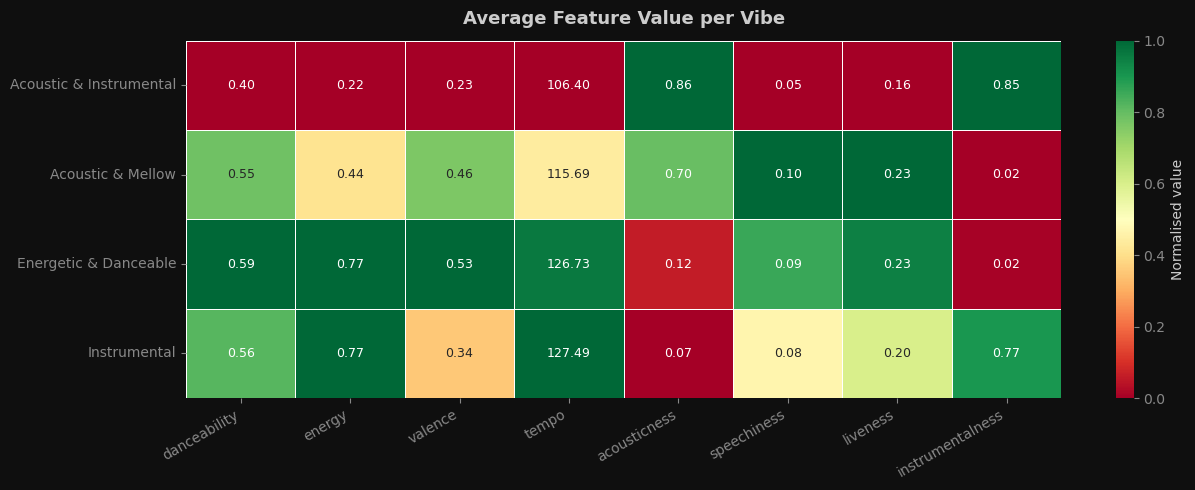

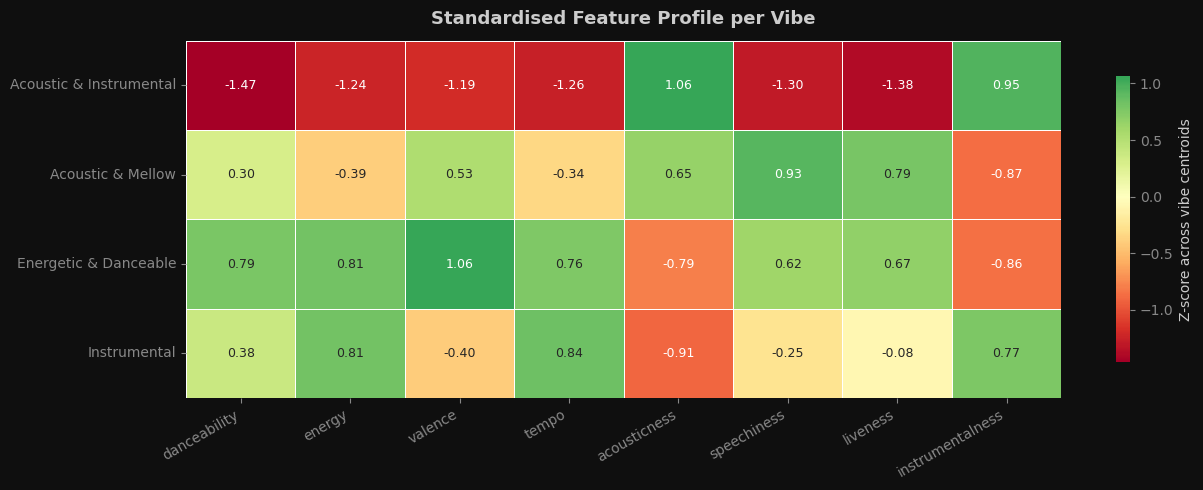

In [50]:
# ────────────── e. Vibe Feature Heatmap (raw mean) ──────────────
heat_features = ["danceability", "energy", "valence", "tempo",
                 "acousticness", "speechiness", "liveness", "instrumentalness"]

heatmap_df = df_deduped.groupby("vibe")[heat_features].mean()
heatmap_norm = (heatmap_df - heatmap_df.min()) / (heatmap_df.max() - heatmap_df.min())
 
fig, ax = plt.subplots(figsize=(13, 5))

sns.heatmap(
    heatmap_norm, 
    annot=heatmap_df.round(2), 
    fmt=".2f",
    cmap="RdYlGn", 
    ax=ax, 
    linewidths=0.5,
    annot_kws={"size": 9},
    cbar_kws={"label": "Normalised value"}
    )

ax.set_title("Average Feature Value per Vibe", pad=12)
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()
plt.close()


# ────────────── f. Standardised Cluster Heatmap (Z-score) ──────────────
cluster_profile = df_deduped.groupby("vibe")[CLUSTER_FEATURES].mean()

# Standardize feature values using Z-score
cluster_profile_z = (
    cluster_profile - cluster_profile.mean(axis=0)
    ) / cluster_profile.std(axis=0)

fig, ax = plt.subplots(figsize=(13, 5))

sns.heatmap(
    cluster_profile_z,
    annot=cluster_profile_z.round(2), fmt=".2f",
    cmap="RdYlGn", center=0, ax=ax, linewidths=0.5,
    annot_kws={"size": 9},
    cbar_kws={"label": "Z-score across vibe centroids", "shrink": 0.8},
)

ax.set_title("Standardised Feature Profile per Vibe", pad=12)
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()
plt.close()

**STEP 6: CLUSTER QUALITY METRICS**

In [53]:
# Check top popular songs per vibe
print("Sample Songs per Vibe:")

for vibe in sorted(df_deduped["vibe"].unique()):
    sample = (df_deduped[df_deduped["vibe"] == vibe]
              .sort_values("popularity", ascending=False)
              [["track_name", "artists", "popularity", "energy", "danceability", "valence"]]
              .head(5))
    
    print(f"\n[{vibe}]")
    print(sample.to_string(index=False))

Sample Songs per Vibe:

[Acoustic & Instrumental]
                               track_name                                       artists  popularity  energy  danceability  valence
                      everything i wanted                                 Billie Eilish          86 0.22500         0.704    0.243
Clean White Noise - Loopable with no fade White Noise Baby Sleep;White Noise for Babies          85 0.00342         0.000    0.000
                                   YKWIM?                                      Yot Club          84 0.53700         0.372    0.228
                           Fourth of July                                Sufjan Stevens          81 0.10400         0.435    0.162
                            Lights Are On                                 Tom Rosenthal          81 0.04000         0.440    0.249

[Acoustic & Mellow]
                             track_name                    artists  popularity  energy  danceability  valence
                             La B

In [55]:
# Cluster quality metrics 
print("Cluster Quality Metrics:")
final_labels = df_deduped["cluster"].iloc[sample_idx].values

final_sil = silhouette_score(X_sample, final_labels)        # Calculate silhouette score
final_db = davies_bouldin_score(X_sample, final_labels)     # Calculate Davies-Bouldin score

print(f"  Silhouette Score: {final_sil:.4f}")
print(f"  Davies-Bouldin: {final_db:.4f})")
print(f"  Inertia: {kmeans.inertia_:,.0f}")

Cluster Quality Metrics:
  Silhouette Score: 0.3165
  Davies-Bouldin: 1.1806)
  Inertia: 17,740


<h4>Section 5: Classification Model</h4>

**STEP 1: PREPARE FEATURES & LABELS**

In [57]:
MODEL_FEATURES = [
    "danceability", "energy", "valence", "tempo",
    "acousticness", "speechiness", "liveness", "instrumentalness",
    "loudness", "explicit", "duration_min",
]

# Create feature matrix (X)
X_clf = df_deduped[MODEL_FEATURES]

# Create target labels (y)
y_clf = df_deduped["vibe"]
 
print(f"Features used for classification:")
for f in MODEL_FEATURES:
    print(f"- {f}")
 
print(f"\nClass distribution:")
for vibe, count in y_clf.value_counts().items():
    print(f"  {vibe:<28}: {count:,} ({count/len(y_clf)*100:.1f}%)")

Features used for classification:
- danceability
- energy
- valence
- tempo
- acousticness
- speechiness
- liveness
- instrumentalness
- loudness
- explicit
- duration_min

Class distribution:
  Energetic & Danceable       : 41,885 (51.8%)
  Acoustic & Mellow           : 21,940 (27.2%)
  Instrumental                : 10,381 (12.8%)
  Acoustic & Instrumental     : 6,594 (8.2%)


**STEP 2: TRAIN / TEST SPLIT**

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Train Set: {len(X_train):,} samples (80%)")
print(f"Test Set: {len(X_test):,} samples (20%)")

Train Set: 64,640 samples (80%)
Test Set: 16,160 samples (20%)


**STEP 3: TRAIN RANDOM FOREST CLASSIFIER**
- Train a supervised model to predict vibe labels using engineered audio features and evaluate performance on unseen test data.

In [62]:
print(" Training Random Forest:")

# Initialize Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=200,           # Number of decision trees
    max_depth=None,             # Allow trees to grow fully
    min_samples_leaf=2,         # Minimum samples required in leaf node
    class_weight="balanced",    # Handle imbalanced vibe classes
    random_state=42,        
    n_jobs=-1,
)

# Train model
rf.fit(X_train, y_train)

# Generate predictions
rf_preds = rf.predict(X_test)
 
# Evaluate model performance
f1_macro = f1_score(y_test, rf_preds, average="macro")          # F1 macro: equal importance for each class
f1_weighted = f1_score(y_test, rf_preds, average="weighted")    # F1 weighted: accounts for class imbalance
acc = accuracy_score(y_test, rf_preds)                          # Accuracy: overall prediction correctness

print(f"  Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1 macro: {f1_macro:.4f}")
print(f"  F1 weighted: {f1_weighted:.4f}")

 Training Random Forest:
  Accuracy: 0.9905  (99.05%)
  F1 macro: 0.9883
  F1 weighted: 0.9905


**STEP 4: Cross-Validation Evaluation**

In [ ]:
print("5-Fold Cross-Validation:")

# Create stratified folds: maintains class proportions in each fold
cv = StratifiedKFold(
    n_splits=5, 
    shuffle=True, 
    random_state=42
    )

# Perform cross-validation
cv_scores = cross_val_score(
    rf, 
    X_train, 
    y_train,
    cv=cv, 
    scoring="f1_macro", 
    n_jobs=-1
    )

print(f"  CV f1_macro scores: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  CV mean: {cv_scores.mean():.4f}")
print(f"  CV std: {cv_scores.std():.4f}")

5-Fold Cross-Validation:
  CV f1_macro scores: ['0.9875', '0.9861', '0.9862', '0.9867', '0.9890']
  CV mean: 0.9871
  CV std: 0.0011


**STEP 5: CLASSIFICATION REPORT**

In [65]:
print("Classification Report:")
print(classification_report(y_test, rf_preds, digits=4))

Classification Report:
                         precision    recall  f1-score   support

Acoustic & Instrumental     0.9790    0.9909    0.9849      1319
      Acoustic & Mellow     0.9906    0.9852    0.9879      4388
  Energetic & Danceable     0.9937    0.9938    0.9937      8377
           Instrumental     0.9851    0.9884    0.9868      2076

               accuracy                         0.9905     16160
              macro avg     0.9871    0.9896    0.9883     16160
           weighted avg     0.9905    0.9905    0.9905     16160



**STEP 6: CONFUSION MATRIX**

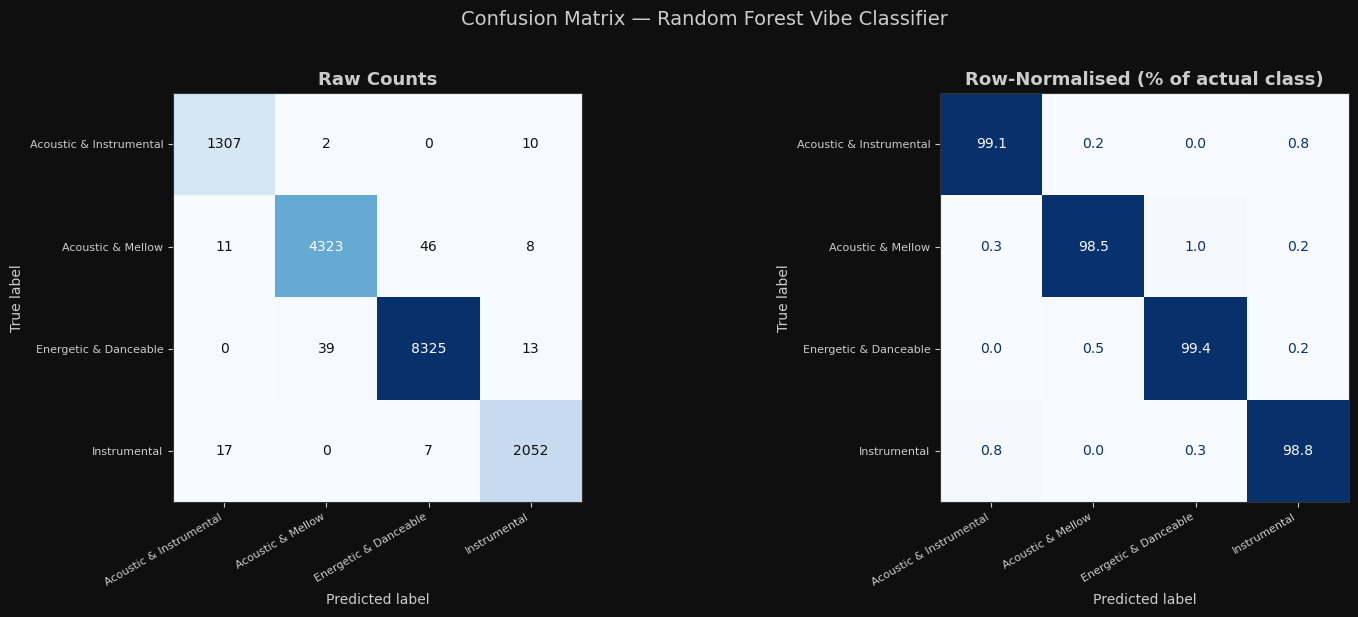

In [67]:
labels = sorted(y_clf.unique())

# Compute confusion matrix
cm = confusion_matrix(y_test, rf_preds, labels=labels)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix — Random Forest Vibe Classifier", fontsize=14, y=1.02)

# ────────────── LEFT: Raw counts confusion matrix ──────────────
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(
    ax=axes[0], 
    colorbar=False, 
    cmap="Blues", 
    values_format="d"
    )

axes[0].set_title("Raw Counts")
axes[0].set_facecolor("#1a1a1a")
axes[0].tick_params(colors="#cccccc")
axes[0].xaxis.label.set_color("#cccccc")
axes[0].yaxis.label.set_color("#cccccc")

thresh0 = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].texts[i * cm.shape[1] + j].set_color(
            "white" if cm[i, j] > thresh0 else "#111111"
        )

plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right", fontsize=8)
plt.setp(axes[0].get_yticklabels(), fontsize=8)

# ────────────── RIGHT: Row-normalized confusion matrix ──────────────
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=labels)

disp2.plot(
    ax=axes[1], 
    colorbar=False, 
    cmap="Blues", 
    values_format=".1f"
    )

axes[1].set_title("Row-Normalised (% of actual class)")
axes[1].set_facecolor("#1a1a1a")
axes[1].tick_params(colors="#cccccc")
axes[1].xaxis.label.set_color("#cccccc")
axes[1].yaxis.label.set_color("#cccccc")

thresh0 = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].texts[i * cm.shape[1] + j].set_color(
            "white" if cm[i, j] > thresh0 else "#111111"
        )

plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right", fontsize=8)
plt.setp(axes[1].get_yticklabels(), fontsize=8)
 
plt.tight_layout()
plt.show()
plt.close()

**STEP 7: FEATURE IMPORTANCE ANALYSIS**

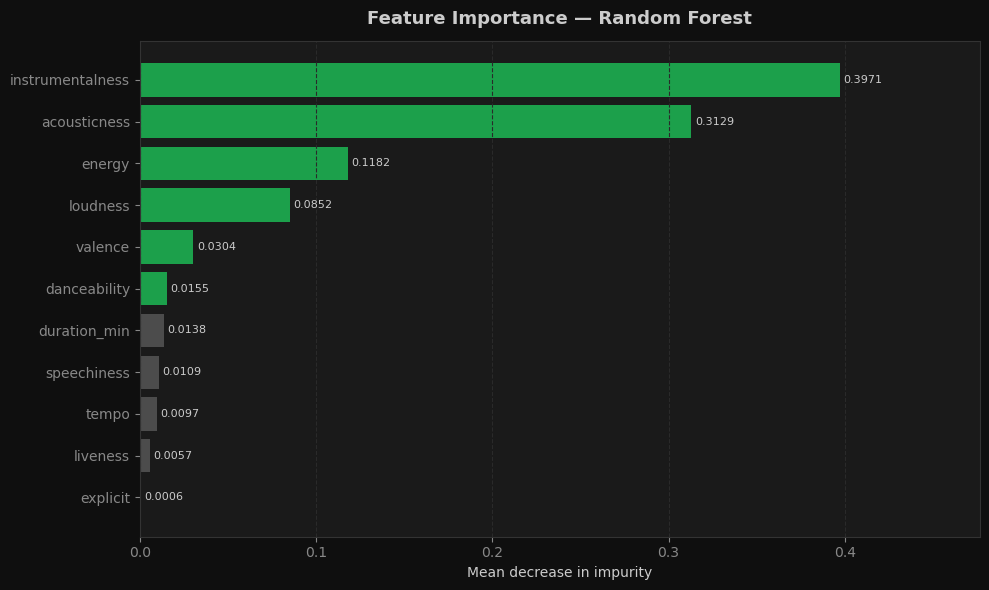

In [68]:
# Extract feature importance scores
importances = pd.Series(rf.feature_importances_, index=MODEL_FEATURES)
importances = importances.sort_values(ascending=True)
 
fig, ax = plt.subplots(figsize=(10, 6))
colors = [SPOTIFY_GREEN if v >= importances.median()    # Green = above median importance
          else "#555555"
          for v in importances.values]

bars = ax.barh(
    importances.index, 
    importances.values,
    color=colors, 
    edgecolor="none", 
    alpha=0.85
    )

for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=8, color="#cccccc")
    
ax.set_title("Feature Importance — Random Forest", pad=12)
ax.set_xlabel("Mean decrease in impurity")
ax.set_xlim(0, importances.max() * 1.2)
ax.grid(True, axis="x")

plt.tight_layout()
plt.show()
plt.close()

**STEP 8: CROSS-VALIDATION PERFORMANCE VALIDATION**

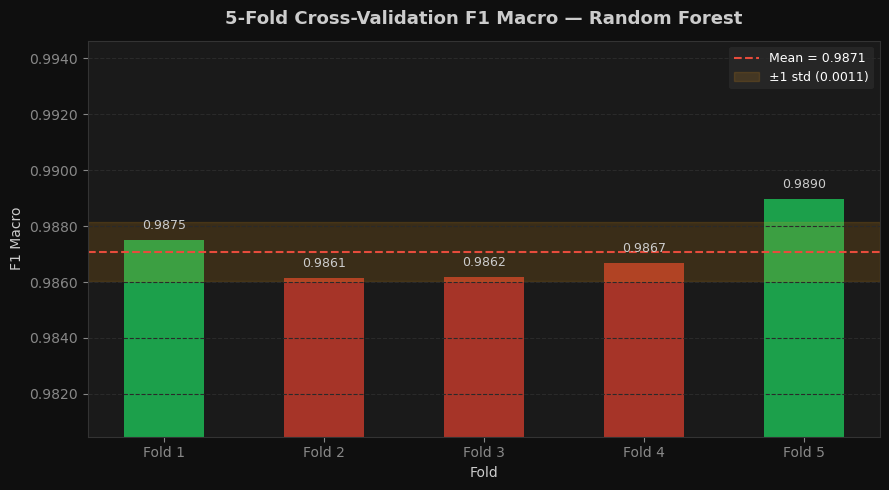

In [72]:
fig, ax = plt.subplots(figsize=(9, 5))
folds = [f"Fold {i+1}" for i in range(len(cv_scores))]
mean_cv = cv_scores.mean()
std_cv = cv_scores.std()
 
bar_colors = [SPOTIFY_GREEN if s >= mean_cv else "#C0392B" for s in cv_scores]  
bars = ax.bar(
    folds, 
    cv_scores, 
    color=bar_colors, 
    alpha=0.85,
    edgecolor="none", 
    width=0.5
    )
 
# Mean line
ax.axhline(mean_cv, color="#E74C3C", lw=1.5, linestyle="--",
           label=f"Mean = {mean_cv:.4f}")
 
# ±1 std band
ax.axhspan(mean_cv - std_cv, mean_cv + std_cv,
           color="#F39C12", alpha=0.15, label=f"±1 std ({std_cv:.4f})")
 
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.0003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9, color="#cccccc")
 
padding = max((cv_scores.max() - cv_scores.min()) * 2, 0.005)
ax.set_ylim(cv_scores.min() - padding, min(cv_scores.max() + padding, 1.0))
 
ax.set_title("5-Fold Cross-Validation F1 Macro — Random Forest", pad=12)
ax.set_ylabel("F1 Macro")
ax.set_xlabel("Fold")
ax.legend(fontsize=9, facecolor="#2a2a2a", edgecolor="none", labelcolor="white")
ax.grid(True, axis="y")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.4f}"))

plt.tight_layout()
plt.show()
plt.close()

**STEP 9: SAVE MODEL**

In [73]:
joblib.dump(rf, "vibe_classifier.pkl")
joblib.dump(vibe_names, "vibe_names.pkl")

print("Models Saved:")
print("  vibe_classifier.pkl  ← trained Random Forest")
print("  vibe_names.pkl       ← cluster")


Models Saved:
  vibe_classifier.pkl  ← trained Random Forest
  vibe_names.pkl       ← cluster


**STEP 10: DEMO (PREDICT NEW SONG)**

In [74]:
new_song = pd.DataFrame([{
    "danceability":     0.72,
    "energy":           0.85,
    "valence":          0.65,
    "tempo":            128.0,
    "acousticness":     0.05,
    "speechiness":      0.08,
    "liveness":         0.12,
    "instrumentalness": 0.001,
    "loudness":         -5.2,
    "explicit":         0,
    "duration_min":     3.5,
}])

# Predict vibe label
predicted_vibe = rf.predict(new_song)[0]

# Predict probability for all classes
predicted_proba = rf.predict_proba(new_song)[0]

proba_df = pd.Series(predicted_proba, index=rf.classes_).sort_values(ascending=False)
 
print(f"Input features:")
for col, val in new_song.iloc[0].items():
    print(f"    {col:<22}: {val}")

print(f"\nPredicted vibe: {predicted_vibe}")

print(f"\nClass probabilities:")
for vibe, prob in proba_df.items():
    bar = "█" * int(prob * 30)
    print(f"    {vibe:<28}: {prob:.4f}  {bar}")

Input features:
    danceability          : 0.72
    energy                : 0.85
    valence               : 0.65
    tempo                 : 128.0
    acousticness          : 0.05
    speechiness           : 0.08
    liveness              : 0.12
    instrumentalness      : 0.001
    loudness              : -5.2
    explicit              : 0.0
    duration_min          : 3.5

Predicted vibe: Energetic & Danceable

Class probabilities:
    Energetic & Danceable       : 1.0000  ██████████████████████████████
    Acoustic & Instrumental     : 0.0000  
    Acoustic & Mellow           : 0.0000  
    Instrumental                : 0.0000  


In [75]:
new_song_2 = pd.DataFrame([{
    "danceability":     0.58,
    "energy":           0.52,
    "valence":          0.48,
    "tempo":            110.0,
    "acousticness":     0.42,
    "speechiness":      0.06,
    "liveness":         0.14,
    "instrumentalness": 0.05,
    "loudness":         -9.5,
    "explicit":         0,
    "duration_min":     3.8,
}])

predicted_vibe_2  = rf.predict(new_song_2)[0]
predicted_proba_2 = rf.predict_proba(new_song_2)[0]
proba_df_2        = pd.Series(predicted_proba_2, index=rf.classes_).sort_values(ascending=False)

print("Input features:")
for col, val in new_song_2.iloc[0].items():
    print(f"    {col:<22}: {val}")

print(f"\nPredicted vibe: {predicted_vibe_2}")

print(f"\nClass probabilities:")
for vibe, prob in proba_df_2.items():
    bar = "█" * int(prob * 30)
    print(f"    {vibe:<28}: {prob:.4f}  {bar}")

Input features:
    danceability          : 0.58
    energy                : 0.52
    valence               : 0.48
    tempo                 : 110.0
    acousticness          : 0.42
    speechiness           : 0.06
    liveness              : 0.14
    instrumentalness      : 0.05
    loudness              : -9.5
    explicit              : 0.0
    duration_min          : 3.8

Predicted vibe: Acoustic & Mellow

Class probabilities:
    Acoustic & Mellow           : 0.9817  █████████████████████████████
    Energetic & Danceable       : 0.0183  
    Acoustic & Instrumental     : 0.0000  
    Instrumental                : 0.0000  


<h4>Phase 4: Recommendation System</h4>

**STEP 1: PREPARE FEATURE MATRIX FOR SIMILARITY**

In [77]:
REC_FEATURES = [
    "danceability", "energy", "valence", "tempo",
    "acousticness", "speechiness", "liveness", "instrumentalness",
    "loudness", "duration_min",
]

# Scale to [0,1] so all features contribute equally to similarity
rec_scaler = MinMaxScaler()
rec_matrix = rec_scaler.fit_transform(df_deduped[REC_FEATURES])

rec_df = df_deduped.reset_index(drop=True)
 
print(f"Feature matrix shape: {rec_matrix.shape}")
print(f"Features used: {REC_FEATURES}")

Feature matrix shape: (80800, 10)
Features used: ['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'speechiness', 'liveness', 'instrumentalness', 'loudness', 'duration_min']


**STEP 2: RECOMMENDATION FUNCTION**

In [89]:
# Helper
def recommend(
    input_vector,
    top_n=10,
    vibe_filter=None,
    genre_filter=None,
    exclude_idx=None,
    diverse=False,
):
    """
    Given a scaled input feature vector (1D array),
    return the top_n most similar songs by cosine similarity.
    """

    # Convert input into 2D format for similarity calculation
    input_vector = np.asarray(input_vector).reshape(1, -1)

    # Compute cosine similarity scores
    sims = cosine_similarity(input_vector, rec_matrix).flatten()

    candidate = rec_df.copy()
    candidate["similarity"] = sims

    # Remove songs from recommendation list to avoid recommending the input song itself
    if exclude_idx is not None:
        if isinstance(exclude_idx, int):
            exclude_idx = [exclude_idx]
        candidate = candidate.drop(index=exclude_idx, errors="ignore")

    # Filter recommendations by vibe
    if vibe_filter is not None:
        candidate = candidate[candidate["vibe"] == vibe_filter]

    # Filter recommendations by genre
    if genre_filter is not None:
        candidate = candidate[candidate["track_genre"] == genre_filter]

    # Return empty result if no songs match filters
    if candidate.empty:
        print(f"No songs found matching the given filters.")
        return pd.DataFrame()
    
    # Return top-N per vibe, then re-rank by similarity and take top_n overall
    if diverse:
        candidate = (
            candidate.sort_values("similarity", ascending=False)
                     .groupby("vibe", group_keys=False)
                     .head(max(1, top_n // candidate["vibe"].nunique()))
        )

    # Rank songs by similarity score
    results = (
        candidate.sort_values("similarity", ascending=False)
        .head(top_n)[["track_name", "artists", "track_genre", "vibe", "popularity", "similarity"] + REC_FEATURES]
        .reset_index(drop=True)
    )

    results.index += 1
    return results

In [90]:
# ───────────── Flow 1: Preference-based recommendation ─────────────

print("—" * 10 + " Flow 1: Preference-Based Recommendation " + "—" * 10)
print("  User input: high energy, danceable, happy, fast tempo")

user_prefs = pd.DataFrame([{
    "danceability": 0.80,
    "energy": 0.85,
    "valence": 0.75,
    "tempo": 125.0,
    "acousticness": 0.05,
    "speechiness": 0.07,
    "liveness": 0.12,
    "instrumentalness": 0.01,
    "loudness": -5.0,
    "duration_min": 3.5,
}])

user_prefs = user_prefs[REC_FEATURES]
user_vector = rec_scaler.transform(user_prefs)

recs_pref = recommend(user_vector, top_n=10)

print("\nTop 10 recommendations:")
print(recs_pref[["track_name", "artists", "track_genre", "vibe", "popularity", "similarity"]].to_string())

—————————— Flow 1: Preference-Based Recommendation ——————————
  User input: high energy, danceable, happy, fast tempo

Top 10 recommendations:
                                   track_name                                 artists track_genre                   vibe  popularity  similarity
1           Tere Siva Jag Mein (From "Tadap")  Pritam;Shilpa Rao;Darshan Raval;Charan      indian  Energetic & Danceable          46    0.999457
2                   O'zapft is - Extended Mix                          Finger & Kadel       party  Energetic & Danceable          24    0.999454
3                                 Ik Wil Pils                        FEEST DJ MAARTEN   hardstyle  Energetic & Danceable          24    0.999352
4   Amaranth (aus "Sing meinen Song, Vol. 9")                                     SDP      german  Energetic & Danceable          43    0.999270
5                                      Por Ti                                   Jeloz   reggaeton  Energetic & Danceable          45

In [91]:
# ───────────── Flow 2: Preference & vibe filter ─────────────

print("—" * 10 + " Flow 2: Preference + Vibe Filter " + "—" * 10)
print("  User input: high energy, danceable, happy, fast tempo")
print("  Filtered to 'Acoustic & Mellow'")

recs_filtered = recommend(user_vector, top_n=10, vibe_filter="Energetic & Danceable")

print("\nTop 10 recommendations (Energetic & Danceable only):")
print(recs_filtered[["track_name", "artists", "track_genre", "vibe", "popularity", "similarity"]].to_string())

—————————— Flow 2: Preference + Vibe Filter ——————————
  User input: high energy, danceable, happy, fast tempo
  Filtered to 'Acoustic & Mellow'

Top 10 recommendations (Energetic & Danceable only):
                                   track_name                                 artists track_genre                   vibe  popularity  similarity
1           Tere Siva Jag Mein (From "Tadap")  Pritam;Shilpa Rao;Darshan Raval;Charan      indian  Energetic & Danceable          46    0.999457
2                   O'zapft is - Extended Mix                          Finger & Kadel       party  Energetic & Danceable          24    0.999454
3                                 Ik Wil Pils                        FEEST DJ MAARTEN   hardstyle  Energetic & Danceable          24    0.999352
4   Amaranth (aus "Sing meinen Song, Vol. 9")                                     SDP      german  Energetic & Danceable          43    0.999270
5                                      Por Ti                               

In [93]:
# ───────────── Flow 3: Song-based recommendation ─────────────
print("—" * 10 + " Flow 3: Song-Based Recommendation " + "—" * 10)

# Helper
def recommend_by_song(song_name, top_n=10, same_vibe=False, genre_filter=None, diverse=False):
    """
    Find songs similar to a given song by name.
    Returns top_n most similar songs, excluding the query song itself.
    """

    matches = rec_df[
        rec_df["track_name"].str.lower().str.contains(
            song_name.lower(), na=False, regex=False
        )
    ]

    if matches.empty:
        print(f"Song '{song_name}' not found in dataset.")
        return None
 
    # Use highest popularity match when multiple songs have similar names
    query = matches.sort_values("popularity", ascending=False).iloc[0]
    query_idx = query.name
    query_vibe = query["vibe"]
    print(f"  Found: '{query['track_name']}' by {query['artists']}")
    print(f"  Vibe: {query_vibe}  |  Genre: {query['track_genre']}")
 
    query_vector = rec_scaler.transform(pd.DataFrame([query[REC_FEATURES]]))
 
    return recommend(
        query_vector, top_n=top_n,
        vibe_filter=query_vibe if same_vibe else None,
        genre_filter=genre_filter,
        exclude_idx=query_idx,
        diverse=diverse,
    )


# Demo 1: find songs similar to "Blinding Lights" (across all vibes)
print("Demo 1: Recommend songs across all vibes")
recs_song = recommend_by_song("Blinding Lights", top_n=10, diverse=True)

if recs_song is not None:
    print(f"\n  Songs similar to 'Blinding Lights' (across all vibes):")
    print(recs_song[["track_name", "artists", "track_genre", "vibe", "popularity", "similarity"]].to_string())

print()
print()


# Demo 2: find songs similar to "Someone Like You" restricted to same vibe
print("Demo 2: Recommend songs with same vibe")
recs_song2 = recommend_by_song("someone like you", top_n=10, same_vibe=True)

if recs_song2 is not None:
    print(f"\n  Songs similar to 'Someone Like You' (same vibe only):")
    print(recs_song2[["track_name", "artists", "track_genre", "vibe", "popularity", "similarity"]].to_string())
# 

—————————— Flow 3: Song-Based Recommendation ——————————
Demo 1: Recommend songs across all vibes
  Found: 'Blinding Lights' by The Weeknd
  Vibe: Energetic & Danceable  |  Genre: pop

  Songs similar to 'Blinding Lights' (across all vibes):
                            track_name                                                   artists track_genre                     vibe  popularity  similarity
1                            POP/STARS  K/DA;Madison Beer;(G)I-DLE;Jaira Burns;League of Legends       k-pop    Energetic & Danceable          73    0.998835
2                      Part-Time Lover                                      Dabin;Claire Ridgely  electronic    Energetic & Danceable          48    0.998700
3              No Hemos Aprendido Nada                                               Viva Suecia     spanish             Instrumental          53    0.967691
4                            The Alien                                                Noisecream        club             Instru

**STEP 3: RECOMMENDATION QUALITY CHECK**

In [98]:
# Check that recommendations aren't all from the same genre/vibe
print("Flow 1 (preference-based) diversity:")
print(f"    Unique vibes: {recs_pref['vibe'].nunique()} / {len(recs_pref)}")
print(f"    Unique genres: {recs_pref['track_genre'].nunique()} / {len(recs_pref)}")
print(f"    Similarity range: {recs_pref['similarity'].min():.4f} – "
      f"{recs_pref['similarity'].max():.4f}")
 
if recs_song is not None:
    print(f"\nFlow 2 (song-based) diversity:")
    print(f"    Unique vibes: {recs_song['vibe'].nunique()} / {len(recs_song)}")
    print(f"    Unique genres: {recs_song['track_genre'].nunique()} / {len(recs_song)}")
    print(f"    Similarity range: {recs_song['similarity'].min():.4f} – "
          f"{recs_song['similarity'].max():.4f}")

Flow 1 (preference-based) diversity:
    Unique vibes: 1 / 10
    Unique genres: 10 / 10
    Similarity range: 0.9988 – 0.9995

Flow 2 (song-based) diversity:
    Unique vibes: 4 / 8
    Unique genres: 7 / 8
    Similarity range: 0.8306 – 0.9988


**STEP 4: SAVE RECOMMENDER COMPONENTS**

In [99]:
joblib.dump(rec_scaler, "rec_scaler.pkl")
np.save("rec_matrix.npy", rec_matrix)
rec_df[["track_id", "track_name", "artists", "track_genre",
        "vibe", "popularity"] + REC_FEATURES].to_csv(
    "rec_catalogue.csv", index=False
)

print("Recommender Saved:")
print("  rec_scaler.pkl     ← fitted MinMaxScaler for rec features")
print("  rec_matrix.npy     ← pre-computed scaled feature matrix")
print("  rec_catalogue.csv  ← song catalogue with features + vibe")

Recommender Saved:
  rec_scaler.pkl     ← fitted MinMaxScaler for rec features
  rec_matrix.npy     ← pre-computed scaled feature matrix
  rec_catalogue.csv  ← song catalogue with features + vibe
